In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

<br>

Reading and data transformation.


In [3]:
downloaded_dataset = pd.read_csv("KDDCup Data 10 Percent.csv", header=None)

print("First 10 Elements from the Dataset - KDDCup Data 10 Percent.csv:")
downloaded_dataset.head(10)

First 10 Elements from the Dataset - KDDCup Data 10 Percent.csv:


,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.00,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.00,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.00,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.00,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.00,0.0,0.0,0.0,0.0,normal.
5,0,tcp,http,SF,217,2032,0,0,0,0,...,59,1.0,0.0,0.02,0.00,0.0,0.0,0.0,0.0,normal.
6,0,tcp,http,SF,212,1940,0,0,0,0,...,69,1.0,0.0,1.00,0.04,0.0,0.0,0.0,0.0,normal.
7,0,tcp,http,SF,159,4087,0,0,0,0,...,79,1.0,0.0,0.09,0.04,0.0,0.0,0.0,0.0,normal.
8,0,tcp,http,SF,210,151,0,0,0,0,...,89,1.0,0.0,0.12,0.04,0.0,0.0,0.0,0.0,normal.
9,0,tcp,http,SF,212,786,0,0,0,1,...,99,1.0,0.0,0.12,0.05,0.0,0.0,0.0,0.0,normal.


In [4]:
print("Last 10 Elements from the Dataset - KDDCup Data 10 Percent.csv:")
downloaded_dataset.tail(10)

Last 10 Elements from the Dataset - KDDCup Data 10 Percent.csv:


,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
494011,0,tcp,http,SF,308,662,0,0,0,0,...,255,1.0,0.0,0.03,0.06,0.00,0.01,0.0,0.0,normal.
494012,0,tcp,http,SF,291,1862,0,0,0,0,...,255,1.0,0.0,0.02,0.05,0.00,0.01,0.0,0.0,normal.
494013,0,tcp,http,SF,289,244,0,0,0,0,...,255,1.0,0.0,0.02,0.05,0.00,0.01,0.0,0.0,normal.
494014,0,tcp,http,SF,306,662,0,0,0,0,...,255,1.0,0.0,0.02,0.05,0.00,0.01,0.0,0.0,normal.
494015,0,tcp,http,SF,289,1862,0,0,0,0,...,255,1.0,0.0,0.01,0.05,0.00,0.01,0.0,0.0,normal.
494016,0,tcp,http,SF,310,1881,0,0,0,0,...,255,1.0,0.0,0.01,0.05,0.00,0.01,0.0,0.0,normal.
494017,0,tcp,http,SF,282,2286,0,0,0,0,...,255,1.0,0.0,0.17,0.05,0.00,0.01,0.0,0.0,normal.
494018,0,tcp,http,SF,203,1200,0,0,0,0,...,255,1.0,0.0,0.06,0.05,0.06,0.01,0.0,0.0,normal.
494019,0,tcp,http,SF,291,1200,0,0,0,0,...,255,1.0,0.0,0.04,0.05,0.04,0.01,0.0,0.0,normal.
494020,0,tcp,http,SF,219,1234,0,0,0,0,...,255,1.0,0.0,0.17,0.05,0.00,0.01,0.0,0.0,normal.


In [5]:
with open(
    "kddcup.txt", "r"
) as kddcup:  # A handle for reading the contents in the File: kddcup.txt
    # Opening the contents from the file, in order to be manipulated...
    kddcup_contents = kddcup.read()
    # I have customed/manipulated the data entry here, by slicing
    data = kddcup_contents[182:].strip("\n")
    # the contents from the starting position of 182; because I only want the column names for the Dataset:
    # KDDCup Data 10 Percent.csv

# Now we can itereate the contents from the Dataset: KDDCup Data 10
data_scrapping = data.split("\n")
# Percent.csv, and store them in the empty List Variable: stored_features.

# for contents in data_scrapping:
#     # print(contents)   # Un-Comment this to view the contents stored in the List Variable:
# stored_features...
# -------------------------------------------------- NOTE -------------------------------------------------- #
# So we know the contents in the List Variable: data_scrapping, is an element of a Dictionary type.
#
# List Variable: extracted_data - By observance, we know that each Key is the Column Name, and each Value is
#                                 its corresponding connection.This allows us to seperate both values, so each
#                                 elements are seperated as its singular value.
#
# List Variable: extracted_features - Stores the data entry which will be used for the Dataset: KDDCup Data 10
#                                     Percent.csv Column Names
#
# List Variable: extracted_connections - Stores the data entry which will be used for the Dataset: KDDCup Data
#                                        10 Percent.csv connection type.
extracted_data = [
    word for lists_data in data_scrapping for word in lists_data.split(": ")
]
extracted_features = [
    contents for i, contents in enumerate(extracted_data) if i % 2 == 0
]
extracted_connections = [
    contents for i, contents in enumerate(extracted_data) if i % 2 != 0
]

extracted_features.append("connection")

print("Extracted Features:   ", extracted_features)  # Displays Column Name
# Displays Connection Type
print("Extracted Connections:", extracted_connections)

Extracted Features:    ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'connection']
Extracted Connections: ['continuous.', 'symbolic.', 'symbolic.', 'symbolic.', 'continuous.', 'continuous.', 'symbolic.', 'continuous.', 'continuous.', 'continuous.', 'continuous.', 'symbolic.', 'continuous.', 'continuous.', 'continuou

In [6]:
# This will put the column names in sequence of the List Variable: extracted_features:
downloaded_dataset.columns = extracted_features

# Saved in local directory:
downloaded_dataset.to_csv("KDDCup Data 10 Percent (Edited).csv")

# This becomes the dataset for current use:
edited_dataset = pd.read_csv("KDDCup Data 10 Percent (Edited).csv")

In [7]:
# NOTE: This line of code is used for debugging. When we print the head of the dataset here, we get a new
# dataset.head()  # Column: Unnamed: 0...

# So the column is dropped in this line of code:
dropped_feature = edited_dataset.drop(columns="Unnamed: 0", inplace=True)

In [8]:
print("First 10 Elements from the Dataset - KDDCup Data 10 Percent (Edited).csv:")
edited_dataset[:10]

First 10 Elements from the Dataset - KDDCup Data 10 Percent (Edited).csv:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,connection
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.00,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.00,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.00,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.00,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.00,0.0,0.0,0.0,0.0,normal.
5,0,tcp,http,SF,217,2032,0,0,0,0,...,59,1.0,0.0,0.02,0.00,0.0,0.0,0.0,0.0,normal.
6,0,tcp,http,SF,212,1940,0,0,0,0,...,69,1.0,0.0,1.00,0.04,0.0,0.0,0.0,0.0,normal.
7,0,tcp,http,SF,159,4087,0,0,0,0,...,79,1.0,0.0,0.09,0.04,0.0,0.0,0.0,0.0,normal.
8,0,tcp,http,SF,210,151,0,0,0,0,...,89,1.0,0.0,0.12,0.04,0.0,0.0,0.0,0.0,normal.
9,0,tcp,http,SF,212,786,0,0,0,1,...,99,1.0,0.0,0.12,0.05,0.0,0.0,0.0,0.0,normal.


In [9]:
print("Last 10 Elements from the Dataset - KDDCup Data 10 Percent (Edited).csv:")
edited_dataset[-10:]

Last 10 Elements from the Dataset - KDDCup Data 10 Percent (Edited).csv:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,connection
494011,0,tcp,http,SF,308,662,0,0,0,0,...,255,1.0,0.0,0.03,0.06,0.00,0.01,0.0,0.0,normal.
494012,0,tcp,http,SF,291,1862,0,0,0,0,...,255,1.0,0.0,0.02,0.05,0.00,0.01,0.0,0.0,normal.
494013,0,tcp,http,SF,289,244,0,0,0,0,...,255,1.0,0.0,0.02,0.05,0.00,0.01,0.0,0.0,normal.
494014,0,tcp,http,SF,306,662,0,0,0,0,...,255,1.0,0.0,0.02,0.05,0.00,0.01,0.0,0.0,normal.
494015,0,tcp,http,SF,289,1862,0,0,0,0,...,255,1.0,0.0,0.01,0.05,0.00,0.01,0.0,0.0,normal.
494016,0,tcp,http,SF,310,1881,0,0,0,0,...,255,1.0,0.0,0.01,0.05,0.00,0.01,0.0,0.0,normal.
494017,0,tcp,http,SF,282,2286,0,0,0,0,...,255,1.0,0.0,0.17,0.05,0.00,0.01,0.0,0.0,normal.
494018,0,tcp,http,SF,203,1200,0,0,0,0,...,255,1.0,0.0,0.06,0.05,0.06,0.01,0.0,0.0,normal.
494019,0,tcp,http,SF,291,1200,0,0,0,0,...,255,1.0,0.0,0.04,0.05,0.04,0.01,0.0,0.0,normal.
494020,0,tcp,http,SF,219,1234,0,0,0,0,...,255,1.0,0.0,0.17,0.05,0.00,0.01,0.0,0.0,normal.


<br>

The code below will list out all the column names.


In [10]:
print(list(edited_dataset))

['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'connection']


In [11]:
edited_dataset["connection"].value_counts()

connection
smurf.              280790
neptune.            107201
normal.              97278
back.                 2203
satan.                1589
ipsweep.              1247
portsweep.            1040
warezclient.          1020
teardrop.              979
pod.                   264
nmap.                  231
guess_passwd.           53
buffer_overflow.        30
land.                   21
warezmaster.            20
imap.                   12
rootkit.                10
loadmodule.              9
ftp_write.               8
multihop.                7
phf.                     4
perl.                    3
spy.                     2
Name: count, dtype: int64

<br>

The cell abolve displays counts of each type of connections.

Let's store all the records in a dataframe **_normal_** where connection is 'normal'.


In [12]:
normal = edited_dataset[edited_dataset.connection == "normal."]
normal.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,connection
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.


In [13]:
normal_rows = normal.shape[0]
normal_columns = normal.shape[1]
edited_dataset_rows = edited_dataset.shape[0]
edited_dataset_columns = edited_dataset.shape[1]

print(
    f"The Dataset - normal has {normal_rows:,} rows and {normal_columns} columns."
    + "\n"
    + f"The Dataset - edited_dataset has {edited_dataset_rows:,} rows and {edited_dataset_columns} columns."
)

The Dataset - normal has 97,278 rows and 42 columns.
The Dataset - edited_dataset has 494,021 rows and 42 columns.


<br>

**_Prepare your personalised dataset for this task. Replace '26577' with the last 5 digits of your student number. If it starts with zero, please use 6 as the first digit._**

Save the data in to a csv file using the codes in the cells below.


In [14]:
rows = np.random.choice(edited_dataset.index.values, 24861)
dataset = edited_dataset.loc[rows]

dataset.to_csv("Latest.csv", index=False)

Replace name and number with your name and student number. Write it to a csv file. You are required to use this dataset to complete this task.

<br>


In [15]:
dataset = pd.read_csv("Latest.csv")

print("First 10 Elements from the Dataset - KDDCup Data 10 Percent (Edited).csv:")
dataset[:10]

First 10 Elements from the Dataset - KDDCup Data 10 Percent (Edited).csv:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,connection
0,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,smurf.
1,0,tcp,private,S0,0,0,0,0,0,0,...,1,0.00,0.06,0.0,0.0,1.0,1.0,0.0,0.0,neptune.
2,0,icmp,ecr_i,SF,520,0,0,0,0,0,...,255,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,smurf.
3,0,tcp,private,S0,0,0,0,0,0,0,...,11,0.04,0.05,0.0,0.0,1.0,1.0,0.0,0.0,neptune.
4,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,smurf.
5,0,tcp,private,REJ,0,0,0,0,0,0,...,4,0.02,0.06,0.0,0.0,0.0,0.0,1.0,1.0,neptune.
6,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,smurf.
7,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,smurf.
8,0,tcp,private,S0,0,0,0,0,0,0,...,24,0.09,0.05,0.0,0.0,1.0,1.0,0.0,0.0,neptune.
9,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,smurf.


In [16]:
print("Last 10 Elements from the Dataset - KDDCup Data 10 Percent (Edited).csv:")
dataset[-10:]

Last 10 Elements from the Dataset - KDDCup Data 10 Percent (Edited).csv:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,connection
24851,0,tcp,http,REJ,0,0,0,0,0,0,...,255,1.00,0.00,0.20,0.13,0.0,0.00,1.0,0.80,normal.
24852,0,udp,domain_u,SF,33,0,0,0,0,0,...,28,0.29,0.06,0.29,0.00,0.0,0.00,0.0,0.00,normal.
24853,0,tcp,remote_job,S0,0,0,0,0,0,0,...,6,0.02,0.07,0.00,0.00,1.0,1.00,0.0,0.00,neptune.
24854,0,icmp,ecr_i,SF,520,0,0,0,0,0,...,255,1.00,0.00,1.00,0.00,0.0,0.00,0.0,0.00,smurf.
24855,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.00,0.00,0.0,0.00,0.0,0.00,smurf.
24856,0,udp,private,SF,105,145,0,0,0,0,...,237,0.93,0.01,0.00,0.00,0.0,0.00,0.0,0.00,normal.
24857,0,tcp,private,REJ,0,0,0,0,0,0,...,13,0.05,0.07,0.00,0.00,0.0,0.00,1.0,1.00,neptune.
24858,0,icmp,ecr_i,SF,520,0,0,0,0,0,...,255,1.00,0.00,1.00,0.00,0.0,0.00,0.0,0.00,smurf.
24859,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.00,0.00,0.0,0.00,0.0,0.00,smurf.
24860,0,tcp,http,REJ,0,0,0,0,0,0,...,170,1.00,0.00,0.33,0.05,0.0,0.01,1.0,0.99,normal.


In [17]:
dataset["connection"].value_counts()

connection
smurf.              14206
neptune.             5411
normal.              4751
back.                 138
satan.                 81
ipsweep.               68
portsweep.             62
warezclient.           56
teardrop.              54
pod.                   15
nmap.                  11
guess_passwd.           2
buffer_overflow.        2
loadmodule.             2
land.                   1
imap.                   1
Name: count, dtype: int64

<br>

You will note different counts of the connection. Can you guess why? Write your obesrvation in a Markdown cell below.

**(A):**

<br>


In [18]:
dataset.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,connection
0,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,smurf.
1,0,tcp,private,S0,0,0,0,0,0,0,...,1,0.00,0.06,0.0,0.0,1.0,1.0,0.0,0.0,neptune.
2,0,icmp,ecr_i,SF,520,0,0,0,0,0,...,255,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,smurf.
3,0,tcp,private,S0,0,0,0,0,0,0,...,11,0.04,0.05,0.0,0.0,1.0,1.0,0.0,0.0,neptune.
4,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,smurf.


# Data Preprocessing


In [19]:
dataset.dtypes

duration                         int64
protocol_type                      str
service                            str
flag                               str
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

We can note that there are different data types including int, float and object. Object is used to store string values. We would like to transform string to numeric values so that we can apply machine learning methods using sklearn machine learning library. We are going to use sklearn for data preprocessing and machine learning functions.

<br>


In [20]:
dataset.shape

(24861, 42)

In [21]:
dataset.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,24861.000000,2.486100e+04,2.486100e+04,24861.000000,24861.000000,24861.0,24861.000000,24861.000000,24861.000000,24861.000000,...,24861.000000,24861.000000,24861.000000,24861.000000,24861.000000,24861.000000,24861.000000,24861.000000,24861.000000,24861.000000
mean,48.444069,1.875627e+03,8.587079e+02,0.000040,0.007039,0.0,0.040103,0.000080,0.145891,0.040948,...,233.064237,188.655525,0.753387,0.030514,0.603746,0.006881,0.177545,0.177178,0.057877,0.057032
std,731.909394,6.169549e+04,2.410638e+04,0.006342,0.140647,0.0,0.820764,0.008969,0.353004,4.908824,...,63.884229,106.035017,0.410968,0.107461,0.481161,0.044353,0.381195,0.381560,0.229827,0.229218
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4.500000e+01,0.000000e+00,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,255.000000,46.000000,0.390000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.200000e+02,0.000000e+00,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.032000e+03,0.000000e+00,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.040000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,36783.000000,5.133876e+06,2.661605e+06,1.000000,3.000000,0.0,28.000000,1.000000,1.000000,767.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [22]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 24861 entries, 0 to 24860
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     24861 non-null  int64  
 1   protocol_type                24861 non-null  str    
 2   service                      24861 non-null  str    
 3   flag                         24861 non-null  str    
 4   src_bytes                    24861 non-null  int64  
 5   dst_bytes                    24861 non-null  int64  
 6   land                         24861 non-null  int64  
 7   wrong_fragment               24861 non-null  int64  
 8   urgent                       24861 non-null  int64  
 9   hot                          24861 non-null  int64  
 10  num_failed_logins            24861 non-null  int64  
 11  logged_in                    24861 non-null  int64  
 12  num_compromised              24861 non-null  int64  
 13  root_shell                 

In [23]:
dataset.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [24]:
dataset.drop_duplicates(inplace=True)
dataset.shape

(9705, 42)

In [25]:
dataset.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'connection'],
      dtype='str')

In [26]:
obj_cols = dataset.select_dtypes(include=["object"]).columns
print(obj_cols)

Index(['protocol_type', 'service', 'flag', 'connection'], dtype='str')


In [27]:
le = LabelEncoder()
for i in obj_cols:
    dataset[i] = le.fit_transform(dataset[i])

In [28]:
dataset.dtypes

duration                         int64
protocol_type                    int64
service                          int64
flag                             int64
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

In [29]:
columns = list(dataset)
columns = columns[:-1]

In [30]:
scaler = StandardScaler()
sc_data = scaler.fit_transform(dataset[columns])
print(sc_data)

[[-0.10169497 -3.29922755 -1.69600002 ... -0.81240793 -0.39731621
  -0.39138938]
 [-0.10169497 -0.17724984  0.77534922 ...  1.23353218 -0.39731621
  -0.39138938]
 [-0.10169497 -3.29922755 -1.69600002 ... -0.81240793 -0.39731621
  -0.39138938]
 ...
 [-0.10169497  2.94472786  0.77534922 ... -0.81240793 -0.39731621
  -0.39138938]
 [-0.10169497 -0.17724984  0.77534922 ... -0.81240793  2.60981475
   2.6230015 ]
 [-0.10169497 -0.17724984 -1.03697356 ... -0.79194853  2.60981475
   2.59285759]]


In [31]:
transformed_data = pd.DataFrame(sc_data, columns=columns)
transformed_data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,-0.101695,-3.299228,-1.696000,0.872491,-0.021706,-0.055336,-0.010151,-0.080262,0.0,-0.071477,...,0.596443,1.337060,1.225435,-0.457805,3.757788,-0.253479,-0.81598,-0.812408,-0.397316,-0.391389
1,-0.101695,-0.177250,0.775349,-0.345683,-0.032167,-0.055336,-0.010151,-0.080262,0.0,-0.071477,...,0.596443,-0.913887,-0.970260,-0.054452,-0.352488,-0.253479,1.23455,1.233532,-0.397316,-0.391389
2,-0.101695,-3.299228,-1.696000,0.872491,-0.026896,-0.055336,-0.010151,-0.080262,0.0,-0.071477,...,0.596443,1.337060,1.225435,-0.457805,3.757788,-0.253479,-0.81598,-0.812408,-0.397316,-0.391389
3,-0.101695,-0.177250,0.775349,-0.345683,-0.032167,-0.055336,-0.010151,-0.080262,0.0,-0.071477,...,0.596443,-0.825267,-0.882432,-0.121678,-0.352488,-0.253479,1.23455,1.233532,-0.397316,-0.391389
4,-0.101695,-3.299228,-1.696000,0.872491,-0.021706,-0.055336,-0.010151,-0.080262,0.0,-0.071477,...,0.596443,1.337060,1.225435,-0.457805,3.757788,-0.253479,-0.81598,-0.812408,-0.397316,-0.391389


In [32]:
full = pd.DataFrame(transformed_data)
full

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,-0.101695,-3.299228,-1.696000,0.872491,-0.021706,-0.055336,-0.010151,-0.080262,0.0,-0.071477,...,0.596443,1.337060,1.225435,-0.457805,3.757788,-0.253479,-0.81598,-0.812408,-0.397316,-0.391389
1,-0.101695,-0.177250,0.775349,-0.345683,-0.032167,-0.055336,-0.010151,-0.080262,0.0,-0.071477,...,0.596443,-0.913887,-0.970260,-0.054452,-0.352488,-0.253479,1.23455,1.233532,-0.397316,-0.391389
2,-0.101695,-3.299228,-1.696000,0.872491,-0.026896,-0.055336,-0.010151,-0.080262,0.0,-0.071477,...,0.596443,1.337060,1.225435,-0.457805,3.757788,-0.253479,-0.81598,-0.812408,-0.397316,-0.391389
3,-0.101695,-0.177250,0.775349,-0.345683,-0.032167,-0.055336,-0.010151,-0.080262,0.0,-0.071477,...,0.596443,-0.825267,-0.882432,-0.121678,-0.352488,-0.253479,1.23455,1.233532,-0.397316,-0.391389
4,-0.101695,-3.299228,-1.696000,0.872491,-0.021706,-0.055336,-0.010151,-0.080262,0.0,-0.071477,...,0.596443,1.337060,1.225435,-0.457805,3.757788,-0.253479,-0.81598,-0.812408,-0.397316,-0.391389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9700,-0.101695,2.944728,-1.943135,0.872491,-0.031832,-0.055336,-0.010151,-0.080262,0.0,-0.071477,...,-1.133268,-0.674613,-0.333508,-0.054452,0.839492,-0.253479,-0.81598,-0.812408,-0.397316,-0.391389
9701,-0.101695,-0.177250,0.857728,-0.345683,-0.032167,-0.055336,-0.010151,-0.080262,0.0,-0.071477,...,0.596443,-0.869577,-0.926346,0.012773,-0.352488,-0.253479,1.23455,1.233532,-0.397316,-0.391389
9702,-0.101695,2.944728,0.775349,0.872491,-0.031102,-0.051574,-0.010151,-0.080262,0.0,-0.071477,...,0.596443,1.177544,1.071737,-0.390580,-0.352488,-0.253479,-0.81598,-0.812408,-0.397316,-0.391389
9703,-0.101695,-0.177250,0.775349,-2.172943,-0.032167,-0.055336,-0.010151,-0.080262,0.0,-0.071477,...,0.596443,-0.807543,-0.860475,0.012773,-0.352488,-0.253479,-0.81598,-0.812408,2.609815,2.623002


In [33]:
full["connection"] = dataset["connection"]
full.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,connection
0,-0.101695,-3.299228,-1.696000,0.872491,-0.021706,-0.055336,-0.010151,-0.080262,0.0,-0.071477,...,1.337060,1.225435,-0.457805,3.757788,-0.253479,-0.81598,-0.812408,-0.397316,-0.391389,13.0
1,-0.101695,-0.177250,0.775349,-0.345683,-0.032167,-0.055336,-0.010151,-0.080262,0.0,-0.071477,...,-0.913887,-0.970260,-0.054452,-0.352488,-0.253479,1.23455,1.233532,-0.397316,-0.391389,7.0
2,-0.101695,-3.299228,-1.696000,0.872491,-0.026896,-0.055336,-0.010151,-0.080262,0.0,-0.071477,...,1.337060,1.225435,-0.457805,3.757788,-0.253479,-0.81598,-0.812408,-0.397316,-0.391389,13.0
3,-0.101695,-0.177250,0.775349,-0.345683,-0.032167,-0.055336,-0.010151,-0.080262,0.0,-0.071477,...,-0.825267,-0.882432,-0.121678,-0.352488,-0.253479,1.23455,1.233532,-0.397316,-0.391389,7.0
4,-0.101695,-3.299228,-1.696000,0.872491,-0.021706,-0.055336,-0.010151,-0.080262,0.0,-0.071477,...,1.337060,1.225435,-0.457805,3.757788,-0.253479,-0.81598,-0.812408,-0.397316,-0.391389,13.0


In [34]:
target = dataset["connection"]
target.head(10)

0     13
1      7
2     13
3      7
4     13
5      7
6     13
8      7
10    13
11     9
Name: connection, dtype: int64

# Insights about the Data


In [35]:
plt.rcParams["figure.figsize"] = (12, 8)

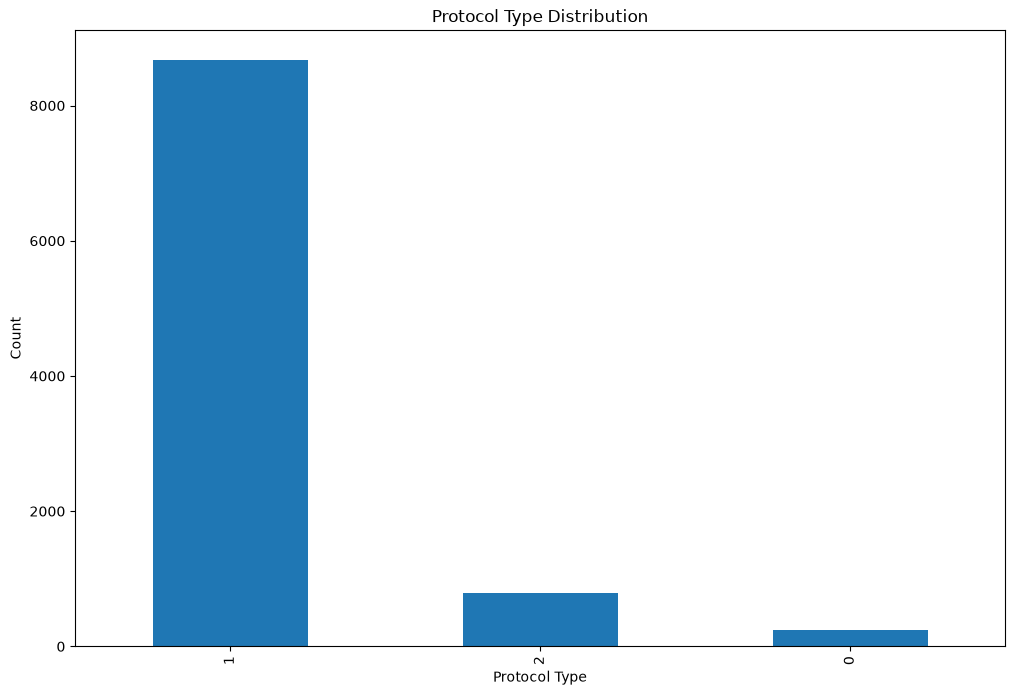

In [36]:
dataset['protocol_type'].value_counts().plot(kind='bar')
plt.xlabel('Protocol Type')
plt.ylabel('Count')
plt.title('Protocol Type Distribution')
plt.show()

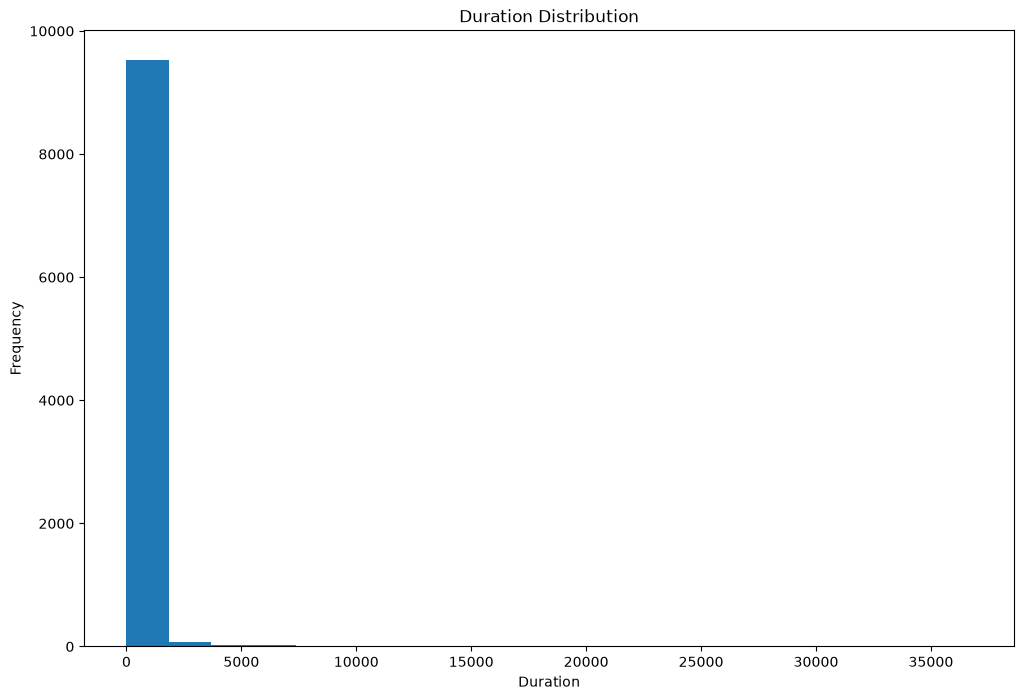

In [37]:
dataset['duration'].plot(kind='hist', bins=20)
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.title('Duration Distribution')
plt.show()

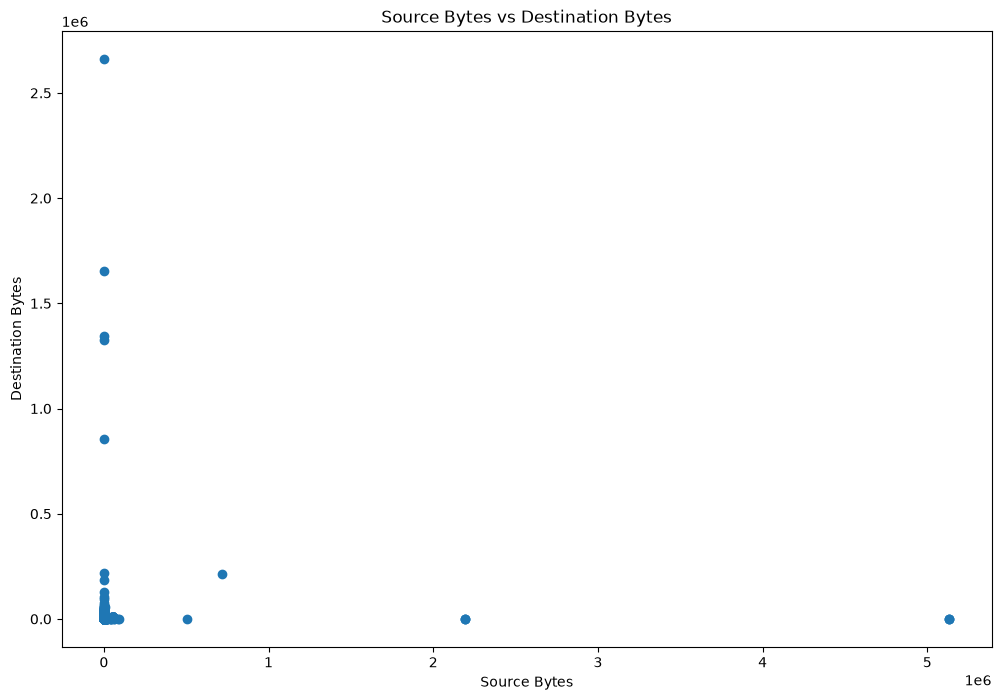

In [38]:
plt.scatter(dataset['src_bytes'], dataset['dst_bytes'])
plt.xlabel('Source Bytes')
plt.ylabel('Destination Bytes')
plt.title('Source Bytes vs Destination Bytes')
plt.show()

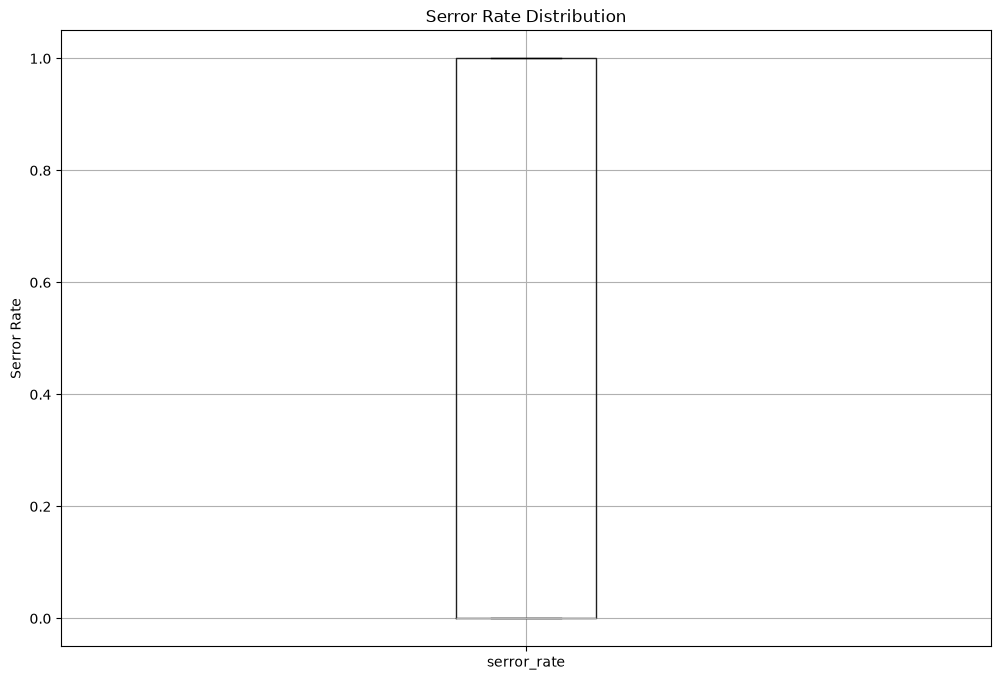

In [39]:
dataset.boxplot(column='serror_rate')
plt.ylabel('Serror Rate')
plt.title('Serror Rate Distribution')
plt.show()

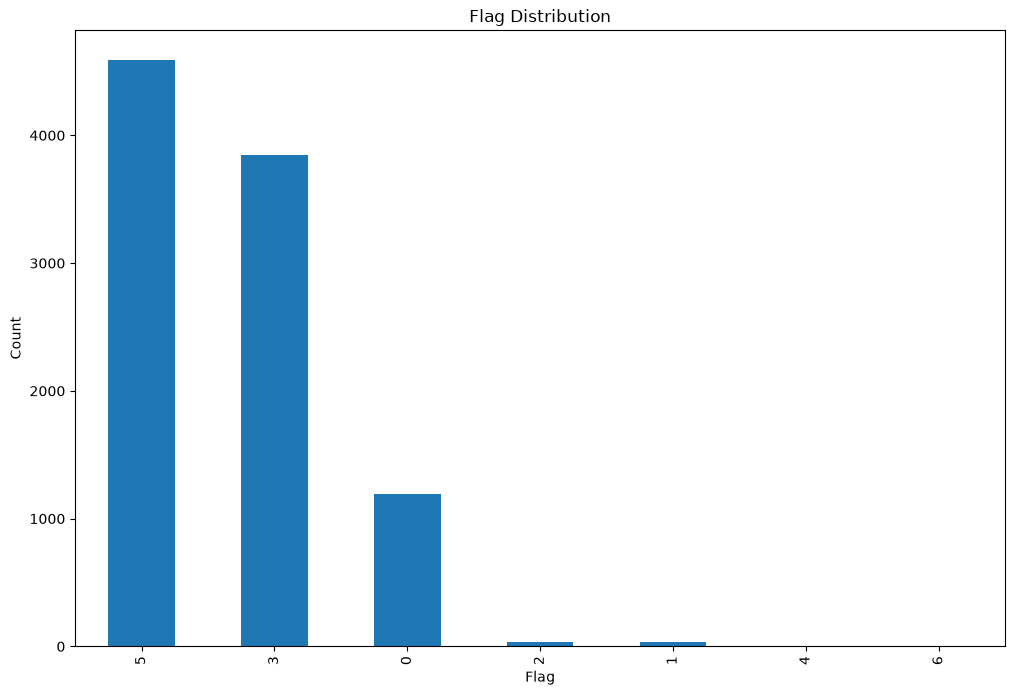

In [40]:
dataset['flag'].value_counts().plot(kind='bar')
plt.xlabel('Flag')
plt.ylabel('Count')
plt.title('Flag Distribution')
plt.show()

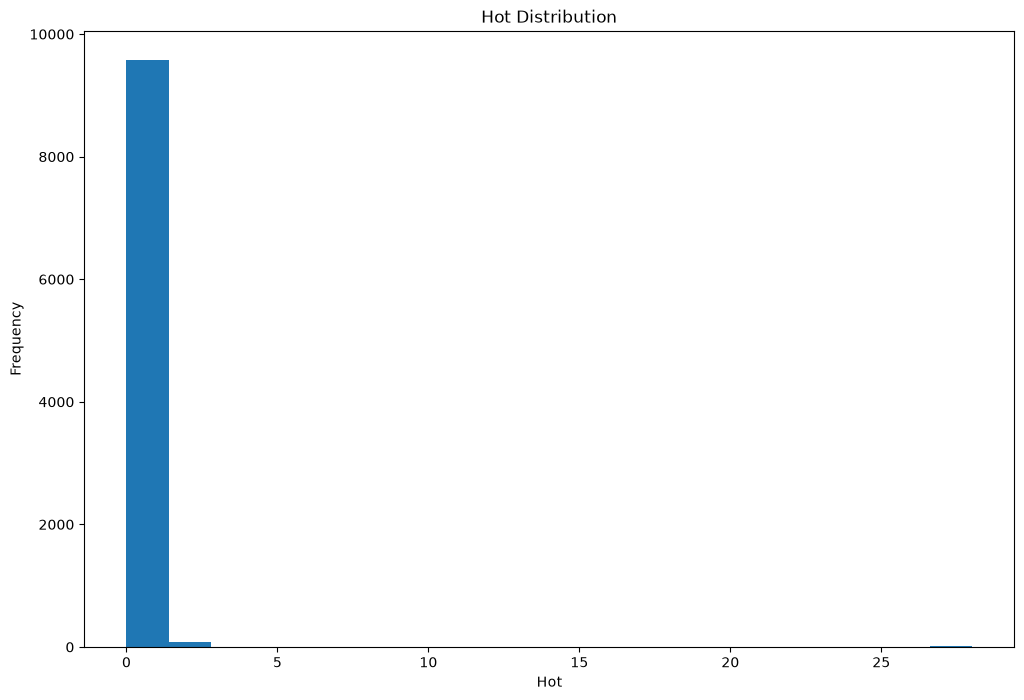

In [41]:
dataset['hot'].plot(kind='hist', bins=20)
plt.xlabel('Hot')
plt.ylabel('Frequency')
plt.title('Hot Distribution')
plt.show()

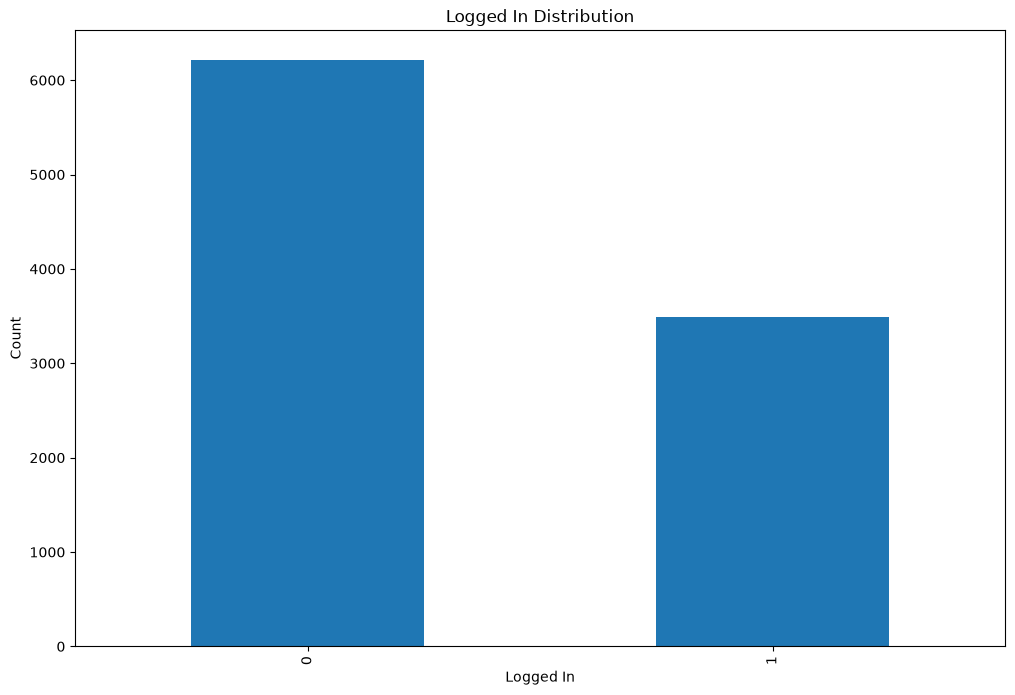

In [42]:
dataset['logged_in'].value_counts().plot(kind='bar')
plt.xlabel('Logged In')
plt.ylabel('Count')
plt.title('Logged In Distribution')
plt.show()

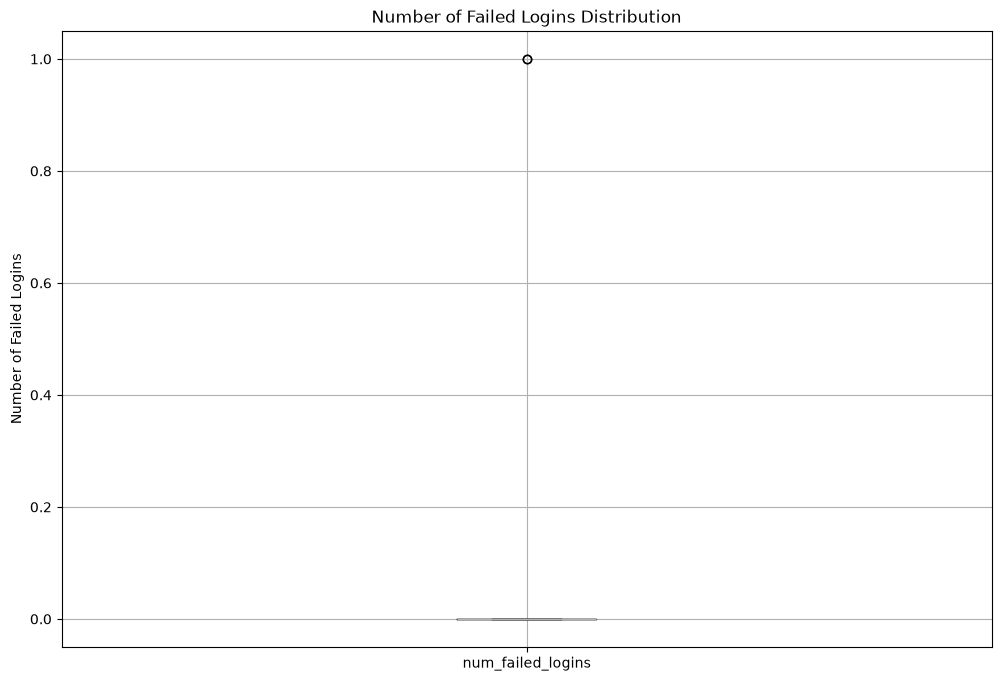

In [43]:
dataset.boxplot(column='num_failed_logins')
plt.ylabel('Number of Failed Logins')
plt.title('Number of Failed Logins Distribution')
plt.show()

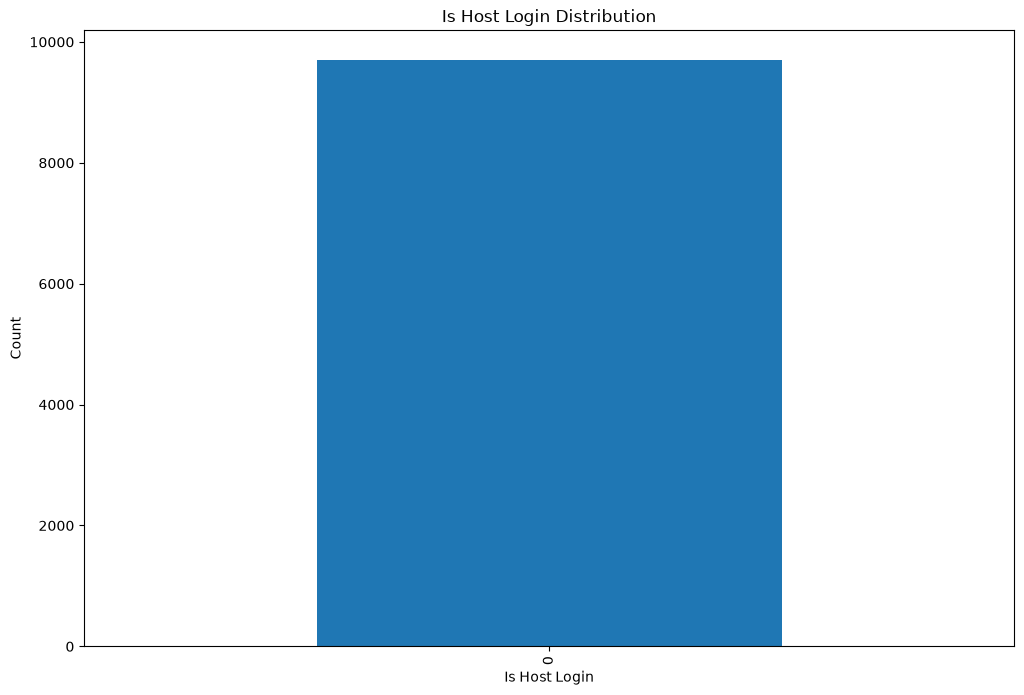

In [44]:
dataset['is_host_login'].value_counts().plot(kind='bar')
plt.xlabel('Is Host Login')
plt.ylabel('Count')
plt.title('Is Host Login Distribution')
plt.show()

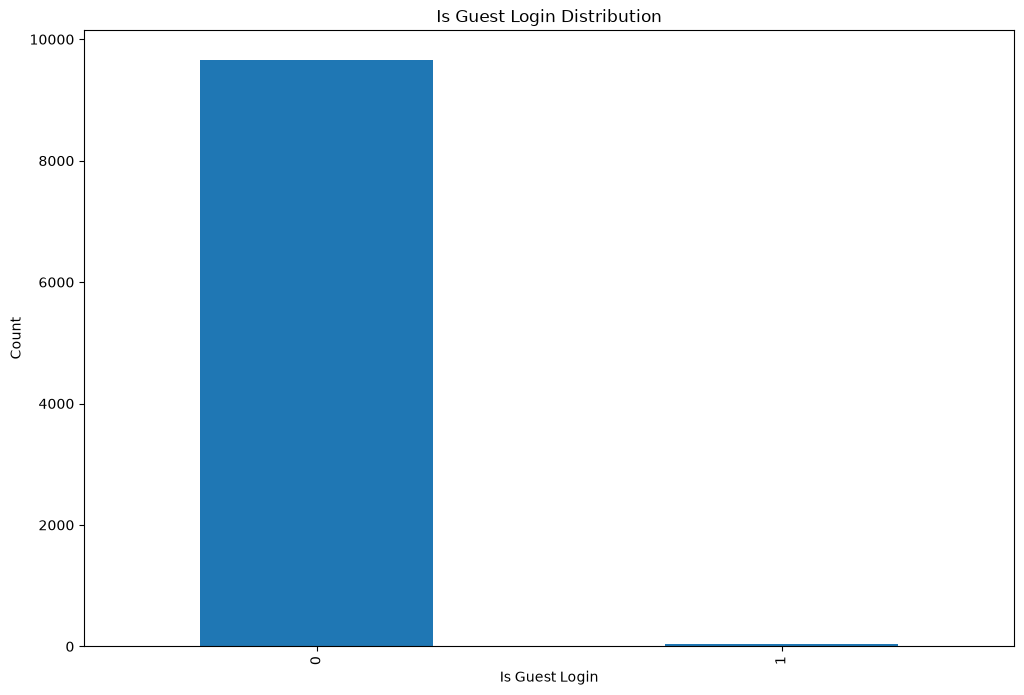

In [45]:
dataset['is_guest_login'].value_counts().plot(kind='bar')
plt.xlabel('Is Guest Login')
plt.ylabel('Count')
plt.title('Is Guest Login Distribution')
plt.show()

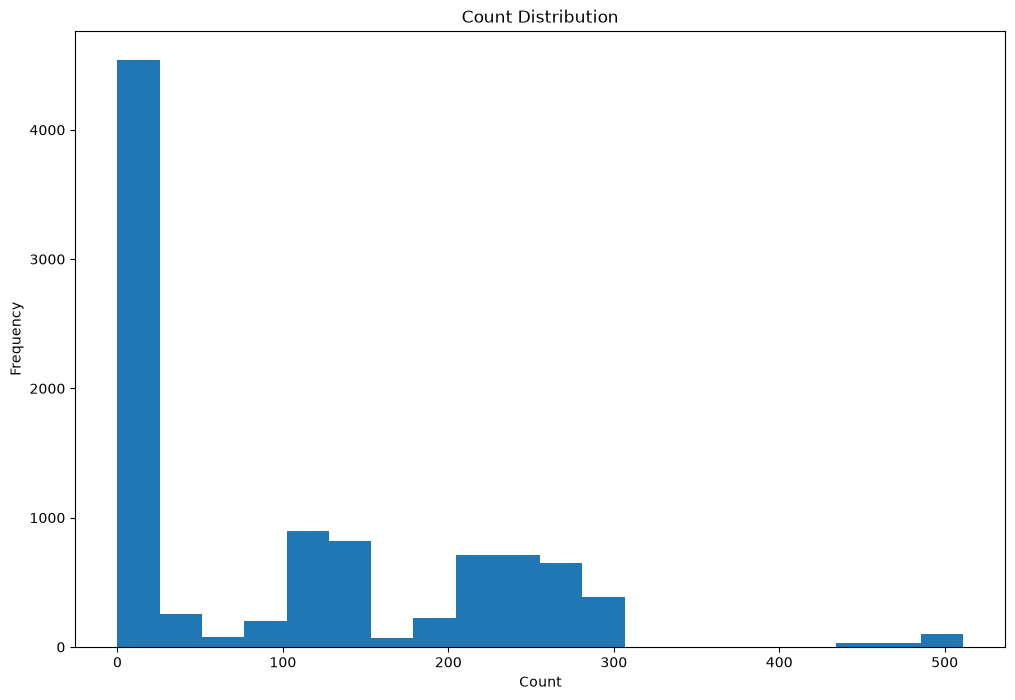

In [46]:
dataset['count'].plot(kind='hist', bins=20)
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.title('Count Distribution')
plt.show()

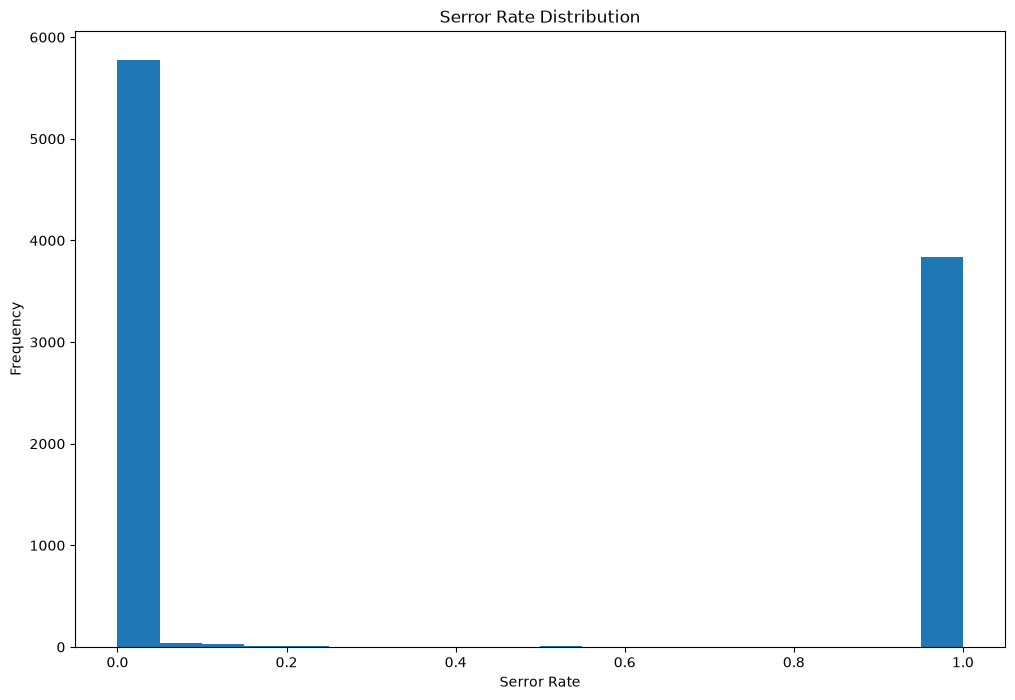

In [47]:
dataset['serror_rate'].plot(kind='hist', bins=20)
plt.xlabel('Serror Rate')
plt.ylabel('Frequency')
plt.title('Serror Rate Distribution')
plt.show()

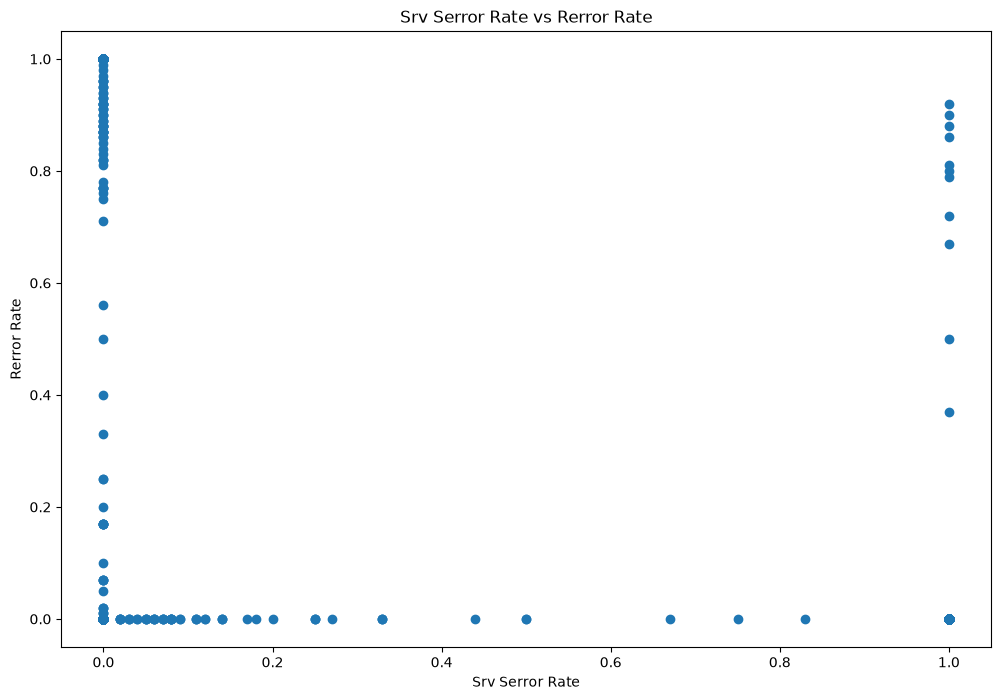

In [48]:
plt.scatter(dataset['srv_serror_rate'], dataset['rerror_rate'])
plt.xlabel('Srv Serror Rate')
plt.ylabel('Rerror Rate')
plt.title('Srv Serror Rate vs Rerror Rate')
plt.show()

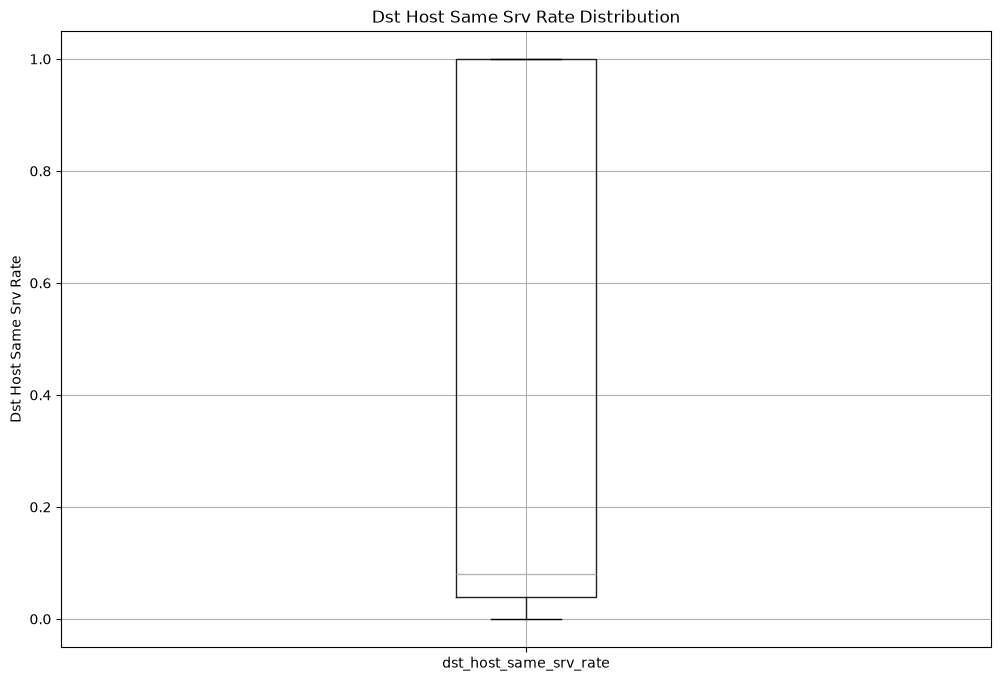

In [49]:
dataset.boxplot(column='dst_host_same_srv_rate')
plt.ylabel('Dst Host Same Srv Rate')
plt.title('Dst Host Same Srv Rate Distribution')
plt.show()

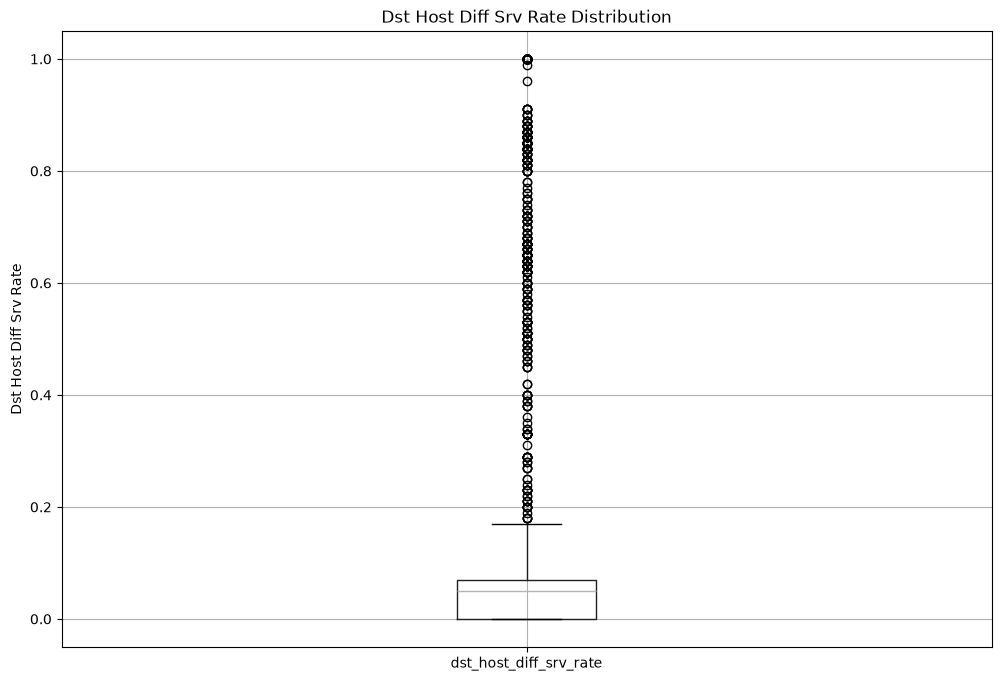

In [50]:
dataset.boxplot(column='dst_host_diff_srv_rate')
plt.ylabel('Dst Host Diff Srv Rate')
plt.title('Dst Host Diff Srv Rate Distribution')
plt.show()

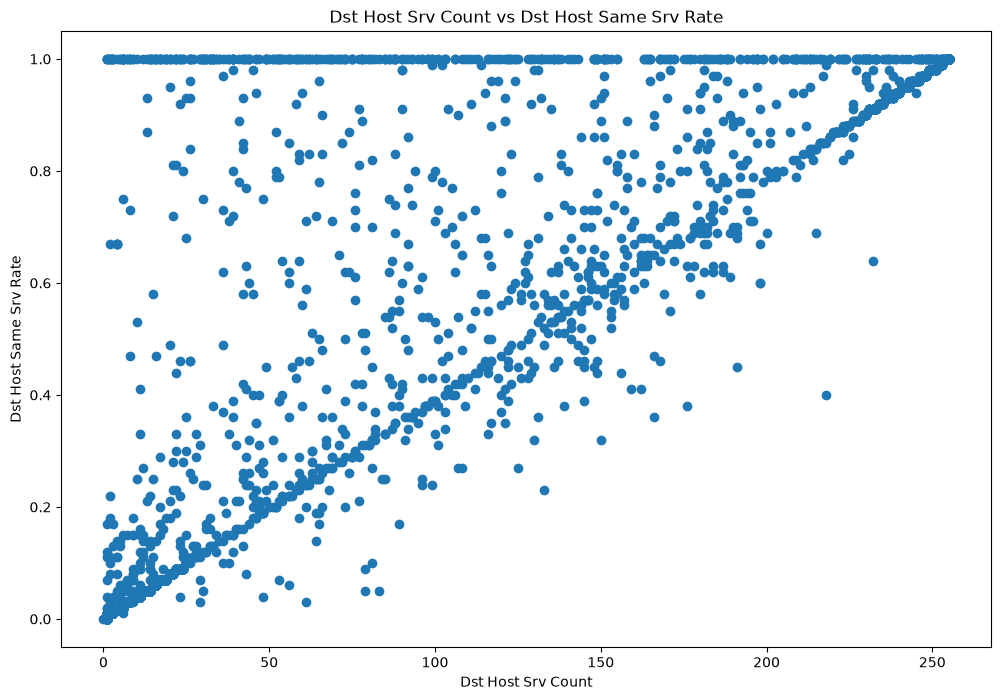

In [51]:
plt.scatter(dataset['dst_host_srv_count'], dataset['dst_host_same_srv_rate'])
plt.xlabel('Dst Host Srv Count')
plt.ylabel('Dst Host Same Srv Rate')
plt.title('Dst Host Srv Count vs Dst Host Same Srv Rate')
plt.show()

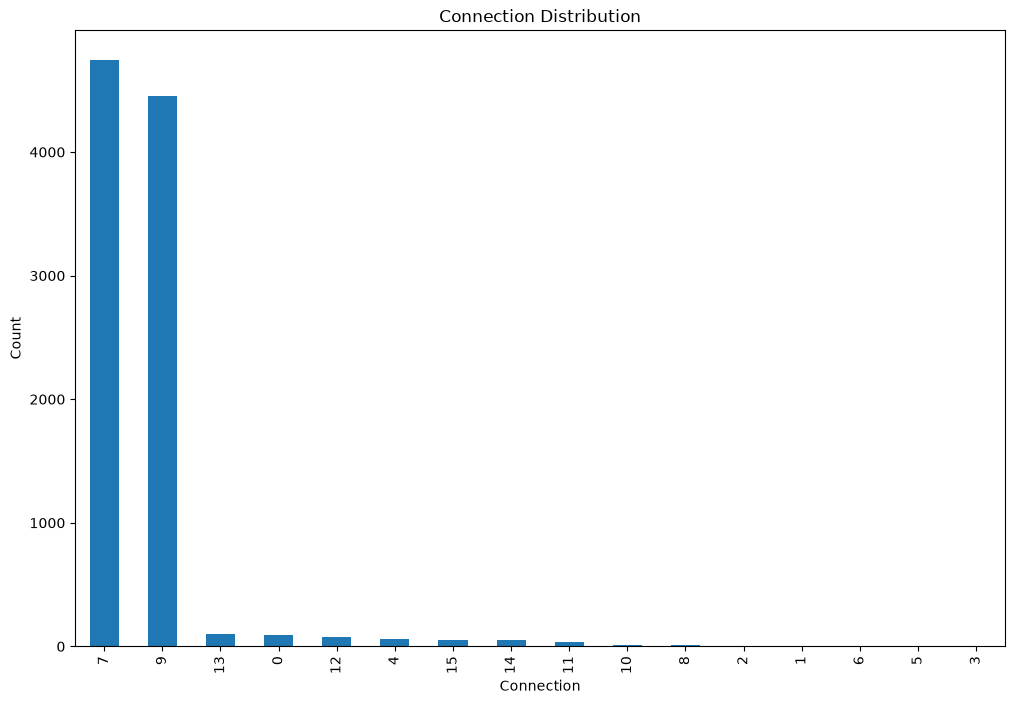

In [52]:
dataset['connection'].value_counts().plot(kind='bar')
plt.xlabel('Connection')
plt.ylabel('Count')
plt.title('Connection Distribution')
plt.show()

<Axes: title={'center': 'Heatmap of Correlation Matrix'}>

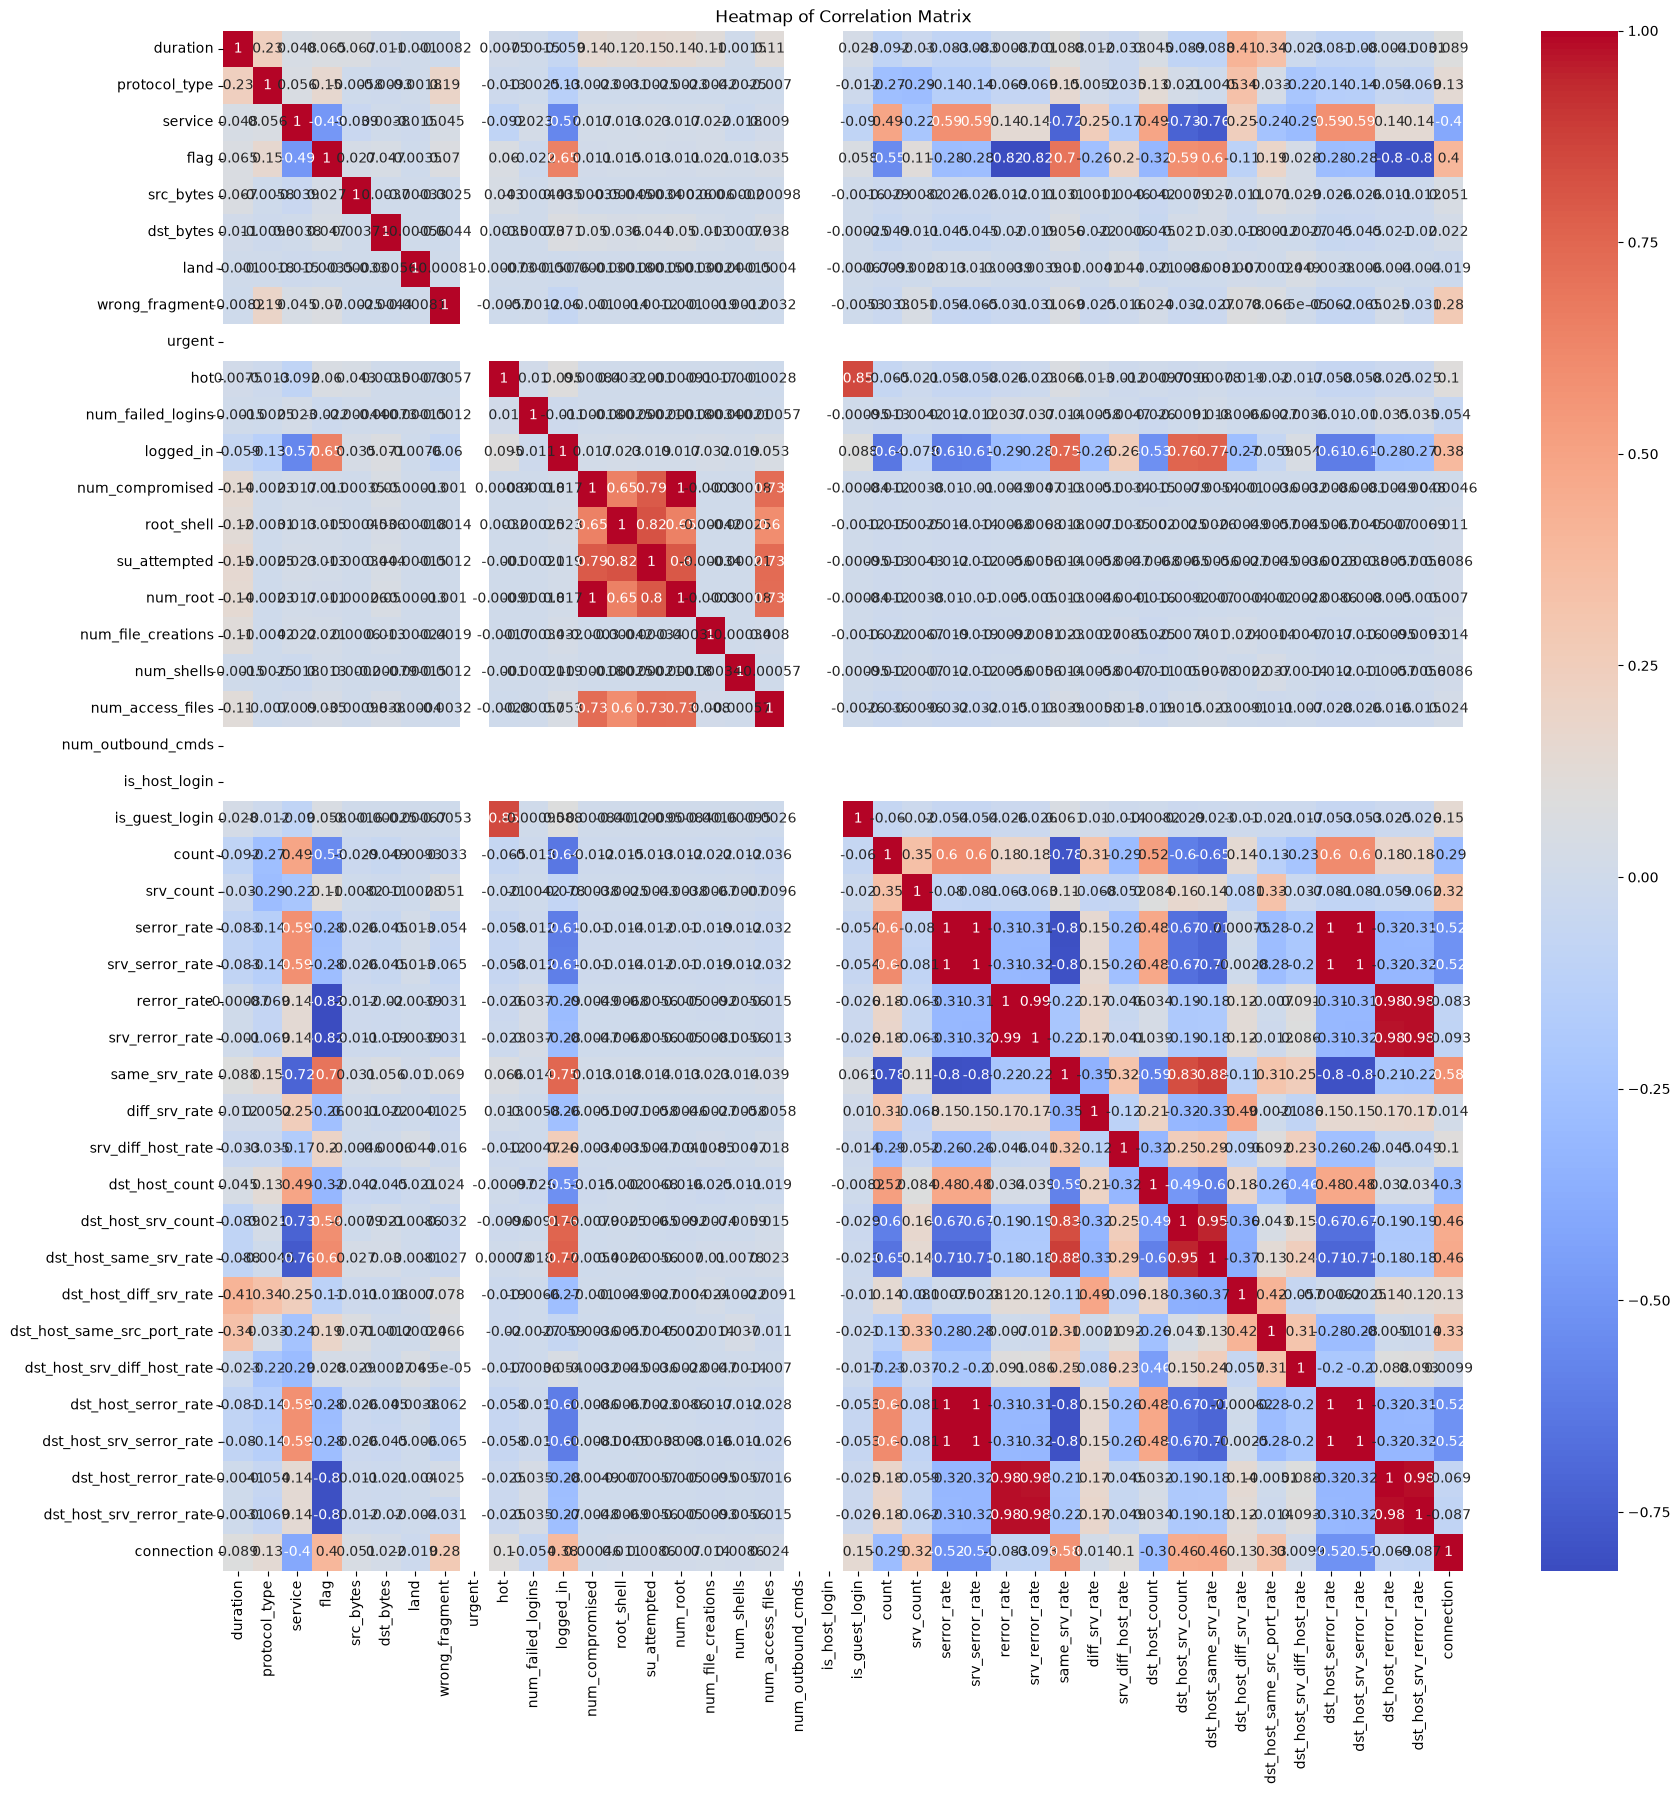

In [53]:
corr = dataset.corr()
plt.figure(figsize=(20, 20))
plt.title('Heatmap of Correlation Matrix')
sns.heatmap(corr, annot=True, cmap='coolwarm')

# Training and Splitting Data set into Test and Train


In [54]:
# Splitting the dataset into the Training set and Test set:
X_train, X_test, y_train, y_test = train_test_split(
    transformed_data, target, test_size=0.3, random_state=8)

# Different Classification Models


## Decision Tree Classifier


In [55]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier()

parameters = [
    {
        "criterion": ["gini", "entropy"],
        "splitter": ["best", "random"],
        "max_features": ["auto", "sqrt", "log2", None],
    }
]


random_search = GridSearchCV(decision_tree, parameters)
random_search.fit(X_train, y_train)
random_search.best_params_

{'criterion': 'entropy', 'max_features': None, 'splitter': 'random'}

In [56]:
print("Evaluation for Decision Tree Classifier".center(75, '_'))

decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)

decision_tree_prediction = decision_tree.predict(X_test)
decision_tree_accuracy = accuracy_score(y_test, decision_tree_prediction)
decision_tree_precision = precision_score(
    y_test, decision_tree_prediction, average="weighted")
decision_tree_recall = recall_score(
    y_test, decision_tree_prediction, average="weighted")
decision_tree_f1_score = f1_score(
    y_test, decision_tree_prediction, average="weighted")

print("Prediciton:    ", decision_tree_prediction)
print('_' * 75)

print("Accuracy:" + "\t" + f"{(decision_tree_accuracy * 100)}%")
print("Precision:" + "\t" + f"{(decision_tree_precision * 100)}%")
print("Recall:" + "\t\t" f"{(decision_tree_recall * 100)}%")
print("F1-Score:" + "\t" + f"{(decision_tree_f1_score * 100)}%")
print('_' * 75)

__________________Evaluation for Decision Tree Classifier__________________
Prediciton:     [9 9 7 ... 7 9 7]
___________________________________________________________________________
Accuracy:	99.38186813186813%
Precision:	99.46660252837093%
Recall:		99.38186813186813%
F1-Score:	99.39833747608368%
___________________________________________________________________________


In [57]:
print("Confusion Matrix For Decision Tree Classifier - 'Labels Test' & 'Prediction':")
print("-" * 93)
print(confusion_matrix(y_test, decision_tree_prediction))

Confusion Matrix For Decision Tree Classifier - 'Labels Test' & 'Prediction':
---------------------------------------------------------------------------------------------
[[  37    0    0    0    0    0    0    0    1    0    0    0    0    0
     0]
 [   0    0    0    0    1    0    0    0    0    0    0    0    0    0
     0]
 [   0    0    1    0    0    0    0    0    0    0    0    0    0    0
     0]
 [   1    0    0    0    0    0    0    0    0    0    0    0    0    0
     0]
 [   0    2    0    0   11    0    0    0    0    0    1    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    1    0    0    0    0    0
     0]
 [   0    0    0    0    0    0 1441    0    0    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    1    0    0    0    0    0    0
     0]
 [   0    0    0    0    1    0    0    0 1297    0    0    0    0    0
     7]
 [   0    0    0    0    0    0    0    0    0    8    0    0    0    0
     0]
 [   0    0    0    0    0  

In [58]:
print(
    "Classification Report For Decision Tree Classifier - 'Labels Test' & 'Prediction':"
)
print("-" * 97)
print(classification_report(y_test, decision_tree_prediction))

Classification Report For Decision Tree Classifier - 'Labels Test' & 'Prediction':
-------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        38
           1       0.00      0.00      0.00         1
           2       1.00      1.00      1.00         1
           3       0.00      0.00      0.00         1
           4       0.85      0.79      0.81        14
           6       0.00      0.00      0.00         1
           7       1.00      1.00      1.00      1441
           8       1.00      1.00      1.00         1
           9       1.00      0.99      1.00      1305
          10       1.00      1.00      1.00         8
          11       0.89      1.00      0.94         8
          12       1.00      0.94      0.97        31
          13       1.00      0.97      0.98        32
          14       1.00      1.00      1.00        16
        

In [59]:
feature_importance = pd.DataFrame(decision_tree.feature_importances_, index=transformed_data.columns, columns=[
                                  'importance']).sort_values('importance', ascending=False)
print(feature_importance)

                             importance
same_srv_rate                  0.804021
srv_count                      0.036244
dst_host_diff_srv_rate         0.029071
num_compromised                0.024992
src_bytes                      0.021196
dst_host_srv_diff_host_rate    0.020955
wrong_fragment                 0.016878
srv_serror_rate                0.009482
service                        0.007498
hot                            0.006756
flag                           0.004898
dst_host_same_src_port_rate    0.004436
dst_bytes                      0.002888
diff_srv_rate                  0.002786
dst_host_count                 0.001906
srv_rerror_rate                0.001128
duration                       0.000915
dst_host_srv_rerror_rate       0.000873
dst_host_same_srv_rate         0.000837
count                          0.000716
num_failed_logins              0.000533
dst_host_srv_count             0.000510
rerror_rate                    0.000460
dst_host_srv_serror_rate       0.000019


<Axes: >

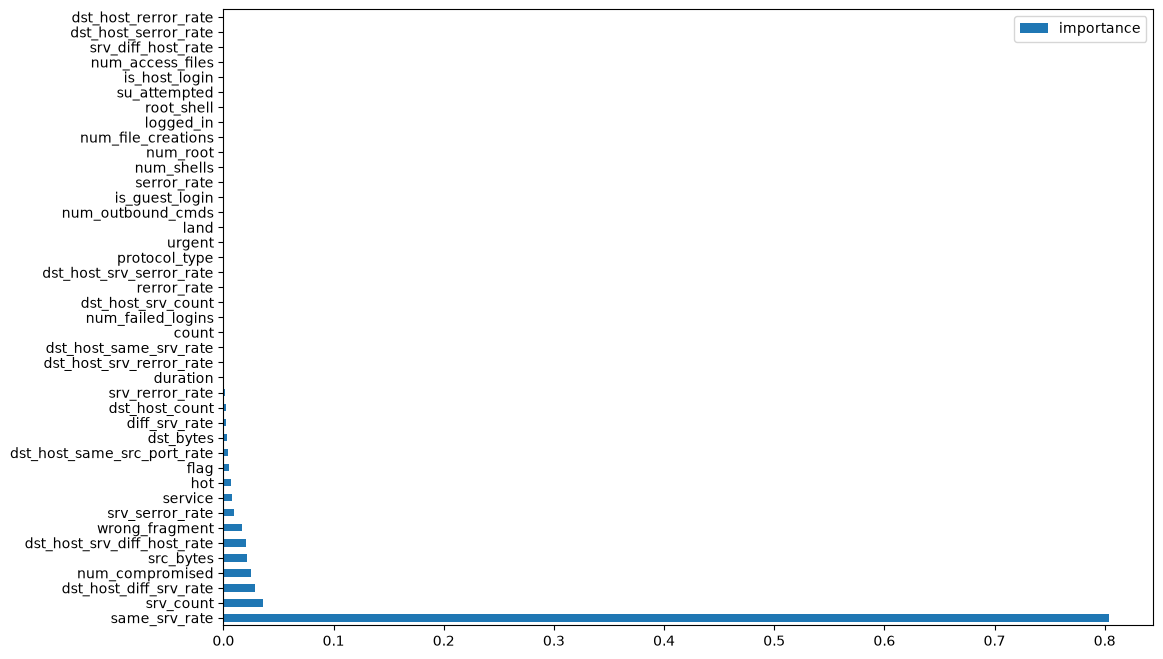

In [60]:
feature_importance.plot(kind="barh")

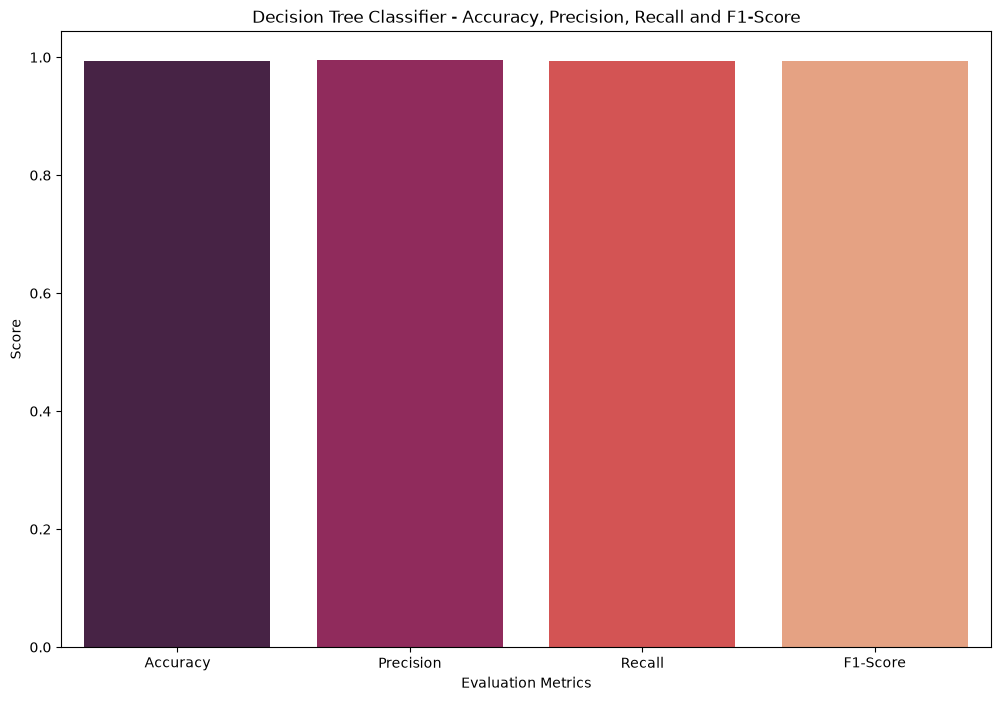

In [61]:
season = ["Accuracy", "Precision", "Recall", "F1-Score"]
season_score = [decision_tree_accuracy, decision_tree_precision,
                decision_tree_recall, decision_tree_f1_score]

sns.barplot(x=season, y=season_score, palette="rocket")
plt.title("Decision Tree Classifier - Accuracy, Precision, Recall and F1-Score")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()

## Random Forest Classifier


In [62]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier()

parameters = [
    {
        "n_estimators": [10, 50, 100, 150, 200],
        "criterion": ["gini", "entropy"],
        "max_features": ["auto", "sqrt", "log2", None],
    }
]

random_search = GridSearchCV(random_forest, parameters)
random_search.fit(X_train, y_train)
random_search.best_params_

{'criterion': 'entropy', 'max_features': 'sqrt', 'n_estimators': 200}

In [63]:
print("Evaluation for Random Forest Classifier".center(75, '_'))

random_forest_classifier = RandomForestClassifier(
    n_estimators=100, random_state=0)
random_forest_classifier.fit(X_train, y_train)

random_forest_classifier_prediction = random_forest_classifier.predict(X_test)
random_forest_classifier_accuracy = accuracy_score(
    y_test, random_forest_classifier_prediction)
random_forest_classifier_precision = precision_score(
    y_test, random_forest_classifier_prediction, average="weighted")
random_forest_classifier_recall = recall_score(
    y_test, random_forest_classifier_prediction, average="weighted")
random_forest_classifier_f1_score = f1_score(
    y_test, random_forest_classifier_prediction, average="weighted")

print("Prediciton:    ", random_forest_classifier_prediction)
print('_' * 75)

print("Accuracy:" + "\t" + f"{(random_forest_classifier_accuracy * 100)}%")
print("Precision:" + "\t" + f"{(random_forest_classifier_precision * 100)}%")
print("Recall:" + "\t\t" f"{(random_forest_classifier_recall * 100)}%")
print("F1-Score:" + "\t" + f"{(random_forest_classifier_f1_score * 100)}%")
print('_' * 75)

__________________Evaluation for Random Forest Classifier__________________
Prediciton:     [9 9 7 ... 7 9 7]
___________________________________________________________________________
Accuracy:	99.79395604395604%
Precision:	99.65753639952725%
Recall:		99.79395604395604%
F1-Score:	99.72495698848547%
___________________________________________________________________________


In [64]:
print("Confusion Matrix For Random Forest Classifier - 'Labels Test' & 'Prediction':")
print("-" * 93)
print(confusion_matrix(y_test, random_forest_classifier_prediction))

Confusion Matrix For Random Forest Classifier - 'Labels Test' & 'Prediction':
---------------------------------------------------------------------------------------------
[[  38    0    0    0    0    0    0    0    0    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    1    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    1    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    1    0    0    0    0    0
     0]
 [   0    0    0    0   14    0    0    0    0    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    1    0    0    0    0    0
     0]
 [   0    0    0    0    0    0 1441    0    0    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    1    0    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0 1305    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    0    8    0    0    0    0
     0]
 [   0    0    0    0    0  

In [65]:
print(
    "Classification Report For Random Forest Classifier - 'Labels Test' & 'Prediction':"
)
print("-" * 97)
print(classification_report(y_test, random_forest_classifier_prediction))

Classification Report For Random Forest Classifier - 'Labels Test' & 'Prediction':
-------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       1.00      1.00      1.00        14
           6       0.00      0.00      0.00         1
           7       1.00      1.00      1.00      1441
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00      1305
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00         8
          12       1.00      0.97      0.98        31
          13       1.00      0.97      0.98        32
          14       1.00      1.00      1.00        16
        

In [66]:
feature_importance = pd.Series(
    random_forest_classifier.feature_importances_, index=transformed_data.columns)
feature_importance

duration                       0.002768
protocol_type                  0.011176
service                        0.014013
flag                           0.100967
src_bytes                      0.085158
dst_bytes                      0.018490
land                           0.000053
wrong_fragment                 0.008191
urgent                         0.000000
hot                            0.009105
num_failed_logins              0.000099
logged_in                      0.011617
num_compromised                0.009405
root_shell                     0.000005
su_attempted                   0.000035
num_root                       0.000105
num_file_creations             0.000005
num_shells                     0.000012
num_access_files               0.000004
num_outbound_cmds              0.000000
is_host_login                  0.000000
is_guest_login                 0.001400
count                          0.131934
srv_count                      0.015168
serror_rate                    0.026556


<Axes: >

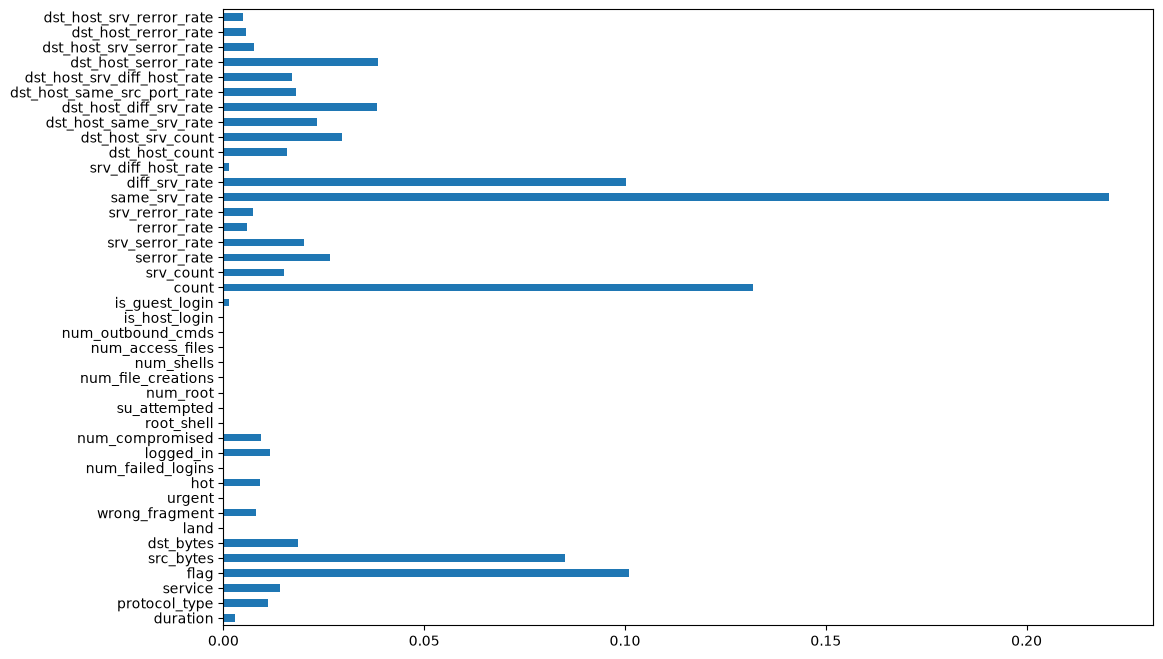

In [67]:
feature_importance.plot(kind="barh")

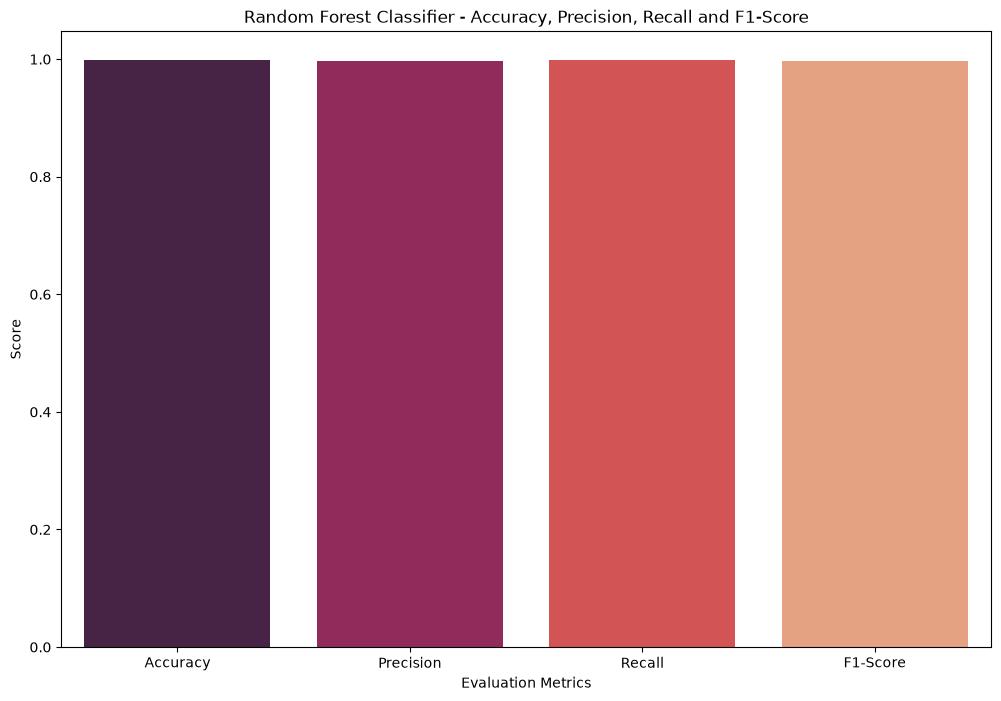

In [68]:
season = ["Accuracy", "Precision", "Recall", "F1-Score"]
season_score = [random_forest_classifier_accuracy, random_forest_classifier_precision,
                random_forest_classifier_recall, random_forest_classifier_f1_score]

sns.barplot(x=season, y=season_score, palette="rocket")
plt.title("Random Forest Classifier - Accuracy, Precision, Recall and F1-Score")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()

## K-Nearest Neighbors


In [69]:
# apply grid search to knn

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_param_grid = [
    {
        'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
]

knn_grid_search = GridSearchCV(knn_model, knn_param_grid)
knn_grid_search.fit(X_train, y_train)
knn_grid_search.best_params_

{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

In [70]:
print("Evaluation for K-Nearest Neighbors".center(75, '_'))

k_nearest_neighbors = KNeighborsClassifier(n_neighbors=5)
k_nearest_neighbors.fit(X_train, y_train)

k_nearest_neighbors_prediction = k_nearest_neighbors.predict(X_test)
k_nearest_neighbors_accuracy = accuracy_score(
    y_test, k_nearest_neighbors_prediction)
k_nearest_neighbors_precision = precision_score(
    y_test, k_nearest_neighbors_prediction, average="weighted")
k_nearest_neighbors_recall = recall_score(
    y_test, k_nearest_neighbors_prediction, average="weighted")
k_nearest_neighbors_f1_score = f1_score(
    y_test, k_nearest_neighbors_prediction, average="weighted")

print("Prediciton:    ", k_nearest_neighbors_prediction)
print('_' * 75)

print("Accuracy:" + "\t" + f"{(k_nearest_neighbors_accuracy * 100)}%")
print("Precision:" + "\t" + f"{(k_nearest_neighbors_precision * 100)}%")
print("Recall:" + "\t\t" f"{(k_nearest_neighbors_recall * 100)}%")
print("F1-Score:" + "\t" + f"{(k_nearest_neighbors_f1_score * 100)}%")
print('_' * 75)

_____________________Evaluation for K-Nearest Neighbors____________________
Prediciton:     [9 9 7 ... 7 9 7]
___________________________________________________________________________
Accuracy:	99.31318681318682%
Precision:	99.22216260398355%
Recall:		99.31318681318682%
F1-Score:	99.23544806414488%
___________________________________________________________________________


In [71]:
print("Confusion Matrix For K-Nearest Neighbors - 'Labels Test' & 'Prediction':")
print('-' * 93)
print(confusion_matrix(y_test, k_nearest_neighbors_prediction))

Confusion Matrix For K-Nearest Neighbors - 'Labels Test' & 'Prediction':
---------------------------------------------------------------------------------------------
[[  36    0    0    0    0    0    0    0    2    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     1]
 [   0    0    0    0    0    0    0    0    1    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    1    0    0    0    0    0
     0]
 [   0    0    0    0   12    0    0    0    1    0    1    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    1    0    0    0    0    0
     0]
 [   0    0    0    0    0    0 1441    0    0    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    1    0    0    0    0    0    0
     0]
 [   0    0    0    0    1    0    0    0 1302    0    1    0    0    0
     1]
 [   0    0    0    0    4    0    0    0    0    4    0    0    0    0
     0]
 [   0    0    0    0    0    0  

In [72]:
print("Classification Report For K-Nearest Neighbors - 'Labels Test' & 'Prediction':")
print('-' * 97)
print(classification_report(y_test, k_nearest_neighbors_prediction))

Classification Report For K-Nearest Neighbors - 'Labels Test' & 'Prediction':
-------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        38
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.71      0.86      0.77        14
           6       0.00      0.00      0.00         1
           7       1.00      1.00      1.00      1441
           8       1.00      1.00      1.00         1
           9       0.99      1.00      0.99      1305
          10       1.00      0.50      0.67         8
          11       0.80      1.00      0.89         8
          12       1.00      0.94      0.97        31
          13       1.00      0.97      0.98        32
          14       1.00      1.00      1.00        16
          15 

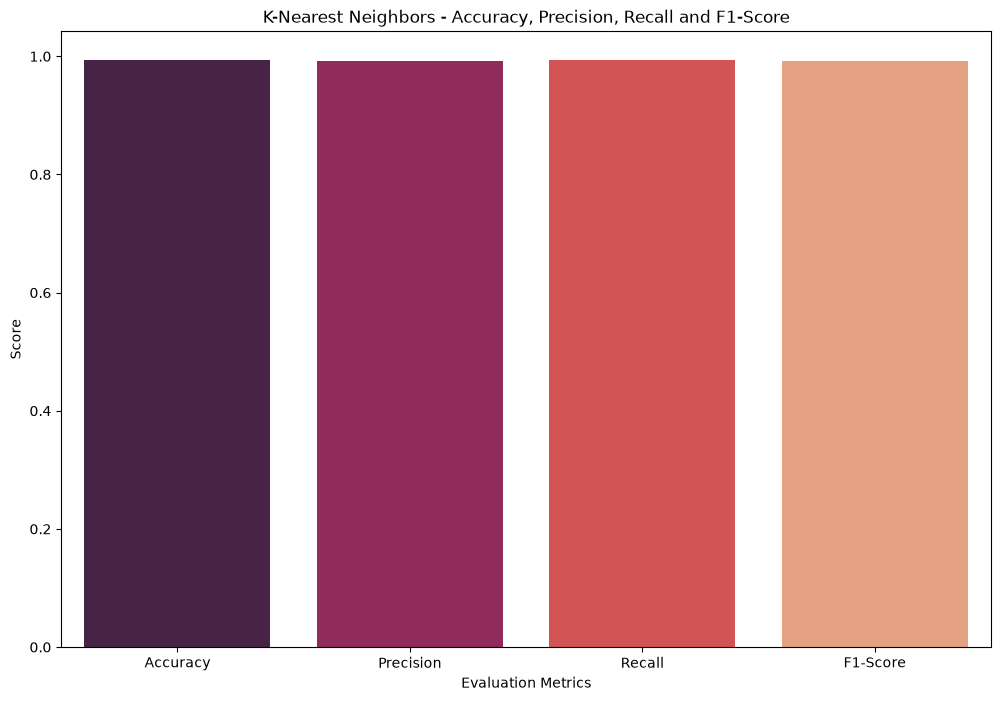

In [73]:
season = ["Accuracy", "Precision", "Recall", "F1-Score"]
season_score = [k_nearest_neighbors_accuracy, k_nearest_neighbors_precision,
                k_nearest_neighbors_recall, k_nearest_neighbors_f1_score]

sns.barplot(x=season, y=season_score, palette="rocket")
plt.title("K-Nearest Neighbors - Accuracy, Precision, Recall and F1-Score")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()

## Ada Boost


In [74]:
# apply grid search to ada boost

from sklearn.ensemble import AdaBoostClassifier

ada_boost_model = AdaBoostClassifier()

ada_boost_param_grid = [
    {
        'n_estimators': [50, 100, 150, 200, 250, 300, 350, 400, 450, 500],
        'learning_rate': [0.001, 0.01, 0.1, 1.0, 10.0],
        # 'algorithm': ['SAMME', 'SAMME.R']
    }
]

ada_boost_grid_search = GridSearchCV(
    ada_boost_model,
    ada_boost_param_grid,
    cv=3,
    n_jobs=-1
)
ada_boost_grid_search.fit(X_train, y_train)
ada_boost_grid_search.best_params_

{'learning_rate': 1.0, 'n_estimators': 400}

In [75]:
print("Evaluation for Ada Boost".center(75, "_"))

ada_boast = AdaBoostClassifier(n_estimators=100, random_state=0)
ada_boast.fit(X_train, y_train)

ada_boost_prediction = ada_boast.predict(X_test)
ada_boost_accuracy = accuracy_score(y_test, ada_boost_prediction)
ada_boost_precision = precision_score(y_test, ada_boost_prediction, average="weighted")
ada_boost_recall = recall_score(y_test, ada_boost_prediction, average="weighted")
ada_boost_f1_score = f1_score(y_test, ada_boost_prediction, average="weighted")

print("Prediciton:    ", ada_boost_prediction)
print("_" * 75)

print("Accuracy:" + "\t" + f"{(ada_boost_accuracy * 100)}%")
print("Precision:" + "\t" + f"{(ada_boost_precision * 100)}%")
print("Recall:" + "\t\t" f"{(ada_boost_recall * 100)}%")
print("F1-Score:" + "\t" + f"{(ada_boost_f1_score * 100)}%")
print("_" * 75)

__________________________Evaluation for Ada Boost_________________________
Prediciton:     [9 9 7 ... 7 9 7]
___________________________________________________________________________
Accuracy:	94.57417582417582%
Precision:	90.10810878712512%
Recall:		94.57417582417582%
F1-Score:	92.26595963829318%
___________________________________________________________________________


In [76]:
print("Confusion Matrix For Ada Boast - 'Labels Test' & 'Prediction':")
print('-' * 93)
print(confusion_matrix(y_test, ada_boost_prediction))

Confusion Matrix For Ada Boast - 'Labels Test' & 'Prediction':
---------------------------------------------------------------------------------------------
[[   0    0    0    0    0    0    0    0   38    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    1    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    1    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    1    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0   14    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    1    0    0    0    0    0
     0]
 [   0    0    0    0    0    0 1433    0    8    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    1    0    0    0    0    0
     0]
 [   0    0    0    0    2    0    6    0 1297    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    0    8    0    0    0    0
     0]
 [   0    0    0    0    0    0    3    0  

In [77]:
print("Classification Report For Ada Boast - 'Labels Test' & 'Prediction':")
print('-' * 97)
print(classification_report(y_test, ada_boost_prediction))

Classification Report For Ada Boast - 'Labels Test' & 'Prediction':
-------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        38
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        14
           6       0.00      0.00      0.00         1
           7       0.97      0.99      0.98      1441
           8       0.00      0.00      0.00         1
           9       0.92      0.99      0.95      1305
          10       1.00      1.00      1.00         8
          11       0.00      0.00      0.00         8
          12       0.00      0.00      0.00        31
          13       0.00      0.00      0.00        32
          14       1.00      1.00      1.00        16
          15       0.00

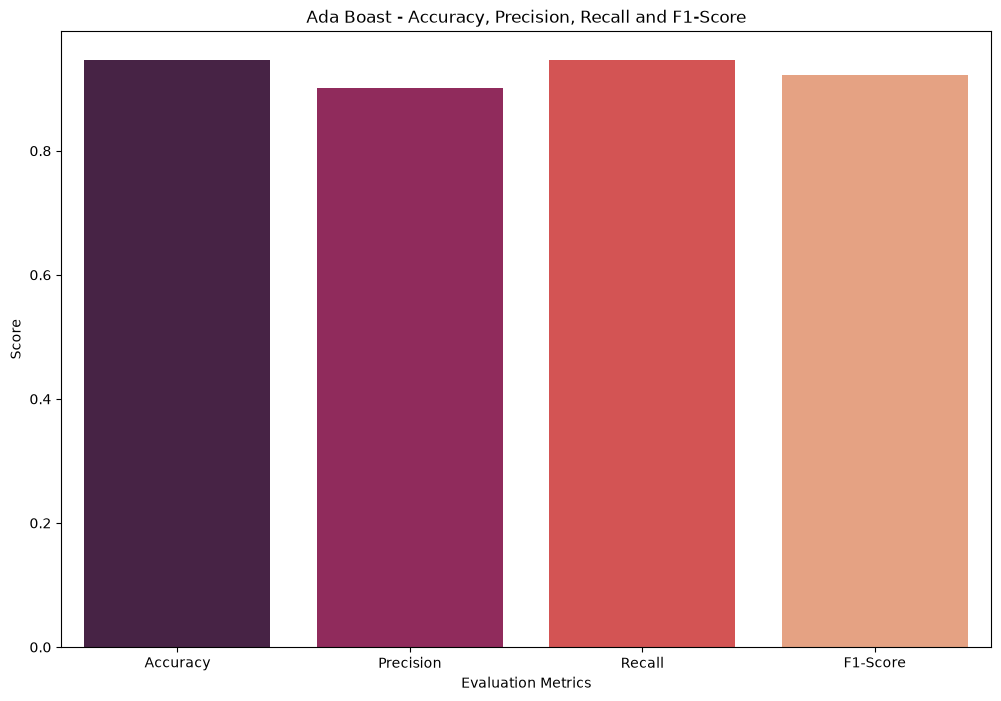

In [78]:
season = ["Accuracy", "Precision", "Recall", "F1-Score"]
season_score = [ada_boost_accuracy, ada_boost_precision,
                ada_boost_recall, ada_boost_f1_score]

sns.barplot(x=season, y=season_score, palette="rocket")
plt.title("Ada Boast - Accuracy, Precision, Recall and F1-Score")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()

## Gradient Boosting


In [79]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

gradient_boost_model = GradientBoostingClassifier(random_state=42)

gradient_boost_param_grid = {
    'loss': ['log_loss', 'exponential'],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'criterion': ['friedman_mse', 'squared_error']
}

gradient_boost_grid_search = GridSearchCV(
    gradient_boost_model,
    gradient_boost_param_grid,
    cv=3,
    n_jobs=-1,
    scoring='accuracy'
)

gradient_boost_grid_search.fit(X_train, y_train)

gradient_boost_grid_search.best_params_

{'criterion': 'friedman_mse',
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'n_estimators': 200}

In [80]:
print("Evaluation for Gradient Boosting".center(75, "_"))

gradient_boosting = GradientBoostingClassifier(
    n_estimators=100, learning_rate=1.0, max_depth=1, random_state=0
)
gradient_boosting.fit(X_train, y_train)

gradient_boosting_prediction = gradient_boosting.predict(X_test)
gradient_boosting_accuracy = accuracy_score(y_test, gradient_boosting_prediction)
gradient_boosting_precision = precision_score(
    y_test, gradient_boosting_prediction, average="weighted"
)
gradient_boosting_recall = recall_score(
    y_test, gradient_boosting_prediction, average="weighted"
)
gradient_boosting_f1_score = f1_score(
    y_test, gradient_boosting_prediction, average="weighted"
)

print("Prediciton:    ", gradient_boosting_prediction)
print("_" * 75)

print("Accuracy:" + "\t" + f"{(gradient_boosting_accuracy * 100)}%")
print("Precision:" + "\t" + f"{(gradient_boosting_precision * 100)}%")
print("Recall:" + "\t\t" f"{(gradient_boosting_recall * 100)}%")
print("F1-Score:" + "\t" + f"{(gradient_boosting_f1_score * 100)}%")
print("_" * 75)

______________________Evaluation for Gradient Boosting_____________________
Prediciton:     [9 9 7 ... 7 9 7]
___________________________________________________________________________
Accuracy:	97.49313186813187%
Precision:	95.9165586043307%
Recall:		97.49313186813187%
F1-Score:	96.55228245831474%
___________________________________________________________________________


In [81]:
print("Confusion Matrix For Gradient Boosting - 'Labels Test' & 'Prediction':")
print('-' * 93)
print(confusion_matrix(y_test, gradient_boosting_prediction))

Confusion Matrix For Gradient Boosting - 'Labels Test' & 'Prediction':
---------------------------------------------------------------------------------------------
[[  36    0    0    0    0    0    0    0    2    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    1    0    0    0    0    0
     0]
 [   0    0    1    0    0    0    0    0    0    0    0    0    0    0
     0]
 [   1    0    0    0    0    0    0    0    0    0    0    0    0    0
     0]
 [   0    0    0    0   11    0    0    0    3    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    1    0    0    0    0    0
     0]
 [   0    0    0    0    0    0 1441    0    0    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    1    0    0    0    0    0
     0]
 [   1    0    0    0    3    0    0    0 1300    0    0    0    1    0
     0]
 [   0    0    0    0    4    0    0    0    0    0    0    0    0    4
     0]
 [   0    0    0    0    0    0    

In [82]:
print("Classification Report For Gradient Boosting - 'Labels Test' & 'Prediction':")
print('-' * 97)
print(classification_report(y_test, gradient_boosting_prediction))

Classification Report For Gradient Boosting - 'Labels Test' & 'Prediction':
-------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        38
           1       0.00      0.00      0.00         1
           2       1.00      1.00      1.00         1
           3       0.00      0.00      0.00         1
           4       0.58      0.79      0.67        14
           6       0.00      0.00      0.00         1
           7       1.00      1.00      1.00      1441
           8       0.00      0.00      0.00         1
           9       0.96      1.00      0.98      1305
          10       0.00      0.00      0.00         8
          11       0.00      0.00      0.00         8
          12       0.00      0.00      0.00        31
          13       0.97      0.97      0.97        32
          14       0.80      1.00      0.89        16
          15   

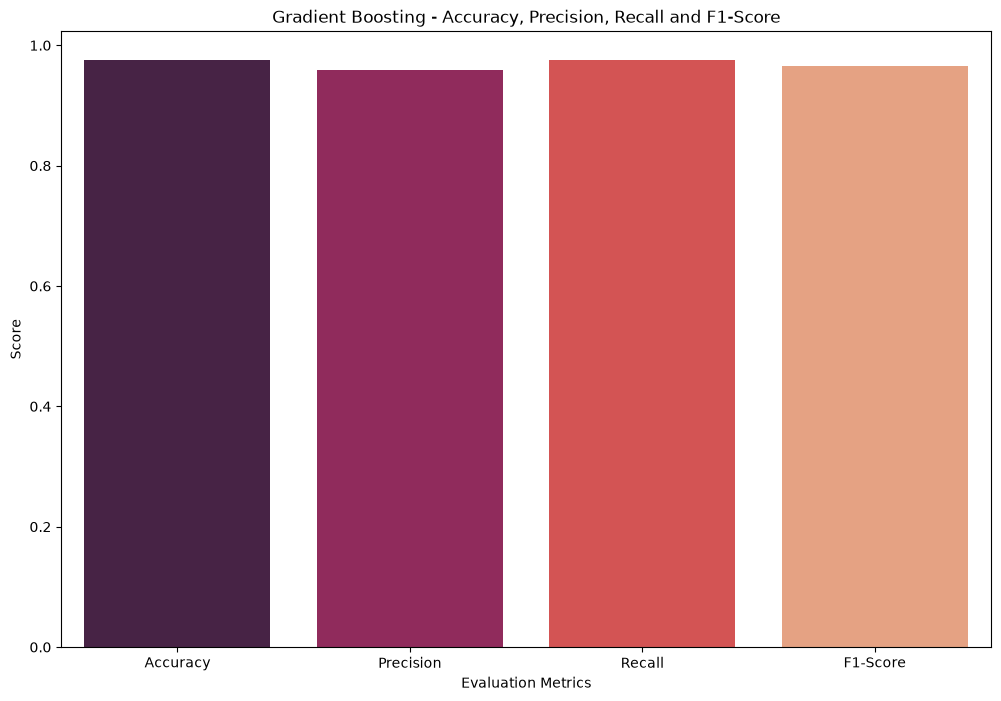

In [83]:
season = ["Accuracy", "Precision", "Recall", "F1-Score"]
season_score = [gradient_boosting_accuracy, gradient_boosting_precision,
                gradient_boosting_recall, gradient_boosting_f1_score]

sns.barplot(x=season, y=season_score, palette="rocket")
plt.title("Gradient Boosting - Accuracy, Precision, Recall and F1-Score")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()

## Hist Gradient Boosting


In [84]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Number of classes:", y_train.nunique())
print("\nClass distribution:")
print(y_train.value_counts().sort_index())

X_train shape: (6793, 41)
y_train shape: (6793,)
Number of classes: 15

Class distribution:
connection
0       54
1        1
2        1
4       44
5        1
6        1
7     3306
8        7
9     3148
10       7
11      31
12      42
13      72
14      38
15      40
Name: count, dtype: int64


In [85]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

hist_gradient_boost_model = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=200,
    max_depth=5,
    random_state=42,
    early_stopping=False
)

hist_gradient_boost_model.fit(X_train, y_train)

hist_prediction = hist_gradient_boost_model.predict(X_test)

hist_accuracy = accuracy_score(y_test, hist_prediction)
hist_precision = precision_score(
    y_test, hist_prediction, average="weighted", zero_division=0
)
hist_recall = recall_score(
    y_test, hist_prediction, average="weighted", zero_division=0
)
hist_f1 = f1_score(
    y_test, hist_prediction, average="weighted", zero_division=0
)

print("Hist Gradient Boosting")
print("Accuracy:", hist_accuracy)
print("Precision:", hist_precision)
print("Recall:", hist_recall)
print("F1 Score:", hist_f1)

Hist Gradient Boosting
Accuracy: 0.8162774725274725
Precision: 0.8151799885225528
Recall: 0.8162774725274725
F1 Score: 0.7986250722744105


In [86]:
print("Evaluation for Hist Gradient Boosting".center(75, "_"))

hist_gradient_boosting = HistGradientBoostingClassifier(
    loss="log_loss",
    learning_rate=0.1,
    max_iter=100,
    max_leaf_nodes=31,
    random_state=0,
    early_stopping=False
)

hist_gradient_boosting.fit(X_train, y_train)

hist_gradient_boosting_prediction = hist_gradient_boosting.predict(X_test)

hist_gradient_boosting_accuracy = accuracy_score(
    y_test, hist_gradient_boosting_prediction
)

hist_gradient_boosting_precision = precision_score(
    y_test, hist_gradient_boosting_prediction,
    average="weighted",
    zero_division=0
)

hist_gradient_boosting_recall = recall_score(
    y_test, hist_gradient_boosting_prediction,
    average="weighted",
    zero_division=0
)

hist_gradient_boosting_f1_score = f1_score(
    y_test, hist_gradient_boosting_prediction,
    average="weighted",
    zero_division=0
)

print("Prediction:   ", hist_gradient_boosting_prediction)
print("_" * 75)

print("Accuracy:\t", f"{hist_gradient_boosting_accuracy * 100:.2f}%")
print("Precision:\t", f"{hist_gradient_boosting_precision * 100:.2f}%")
print("Recall:\t\t", f"{hist_gradient_boosting_recall * 100:.2f}%")
print("F1-Score:\t", f"{hist_gradient_boosting_f1_score * 100:.2f}%")

print("_" * 75)

___________________Evaluation for Hist Gradient Boosting___________________
Prediction:    [9 7 7 ... 7 9 7]
___________________________________________________________________________
Accuracy:	 56.77%
Precision:	 56.64%
Recall:		 56.77%
F1-Score:	 55.34%
___________________________________________________________________________


In [87]:
print("Confusion Matrix For Hist Gradient Boosting - 'Labels Test' & 'Prediction':")
print('-' * 93)
print(confusion_matrix(y_test, hist_gradient_boosting_prediction))

Confusion Matrix For Hist Gradient Boosting - 'Labels Test' & 'Prediction':
---------------------------------------------------------------------------------------------
[[  0   0   0   0   0   0   4   0  34   0   0   0   0   0   0]
 [  0   0   0   0   0   0   1   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   1   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   1   0   0   0   0   0   0]
 [  0   0   0   0   0   0  14   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   1   0   0   0   0   0   0   0   0]
 [ 12   0   0   0   0   0 651   0 775   0   0   0   0   0   3]
 [  0   0   0   0   0   0   1   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 357   0 947   0   0   0   0   0   1]
 [  0   0   0   0   0   0   5   0   3   0   0   0   0   0   0]
 [  0   0   0   0   0   0   2   0   6   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   3   0   0  28   0   0   0]
 [  4   0   0   0   0   0   0   0   1   0   0   0  27   0   0]
 [  0   0  

In [88]:
print("Classification Report For Hist Gradient Boosting - 'Labels Test' & 'Prediction':")
print('-' * 97)
print(classification_report(y_test, hist_gradient_boosting_prediction))

Classification Report For Hist Gradient Boosting - 'Labels Test' & 'Prediction':
-------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        38
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        14
           6       0.00      0.00      0.00         1
           7       0.62      0.45      0.52      1441
           8       0.00      0.00      0.00         1
           9       0.53      0.73      0.61      1305
          10       0.00      0.00      0.00         8
          11       0.00      0.00      0.00         8
          12       1.00      0.90      0.95        31
          13       1.00      0.84      0.92        32
          14       0.00      0.00      0.00        16
          

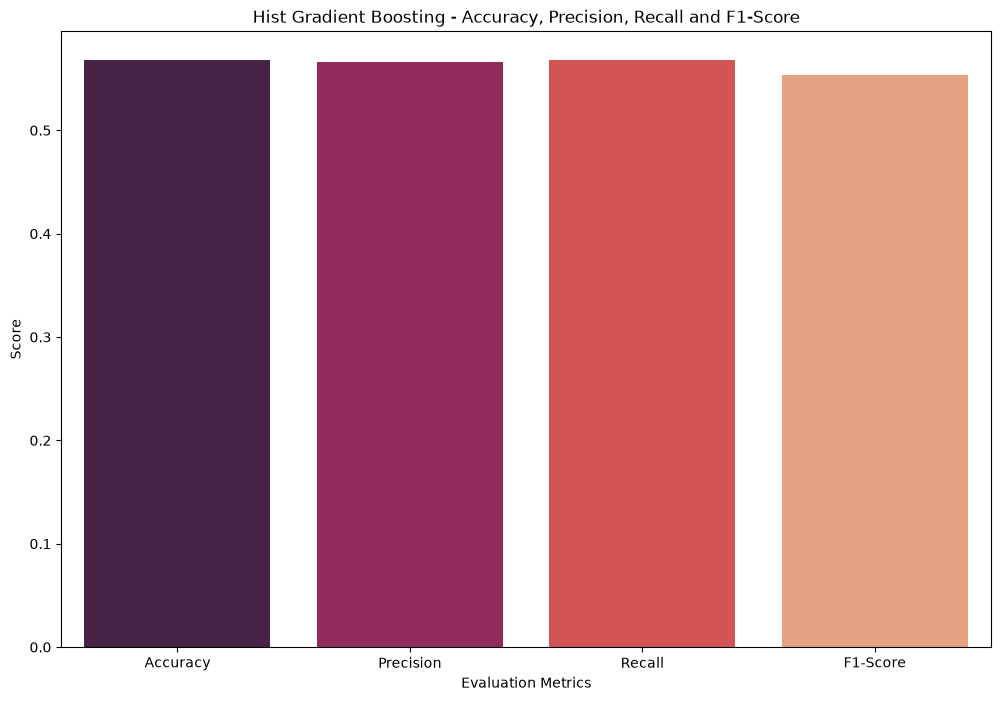

In [89]:
season = ["Accuracy", "Precision", "Recall", "F1-Score"]
season_score = [
    hist_gradient_boosting_accuracy,
    hist_gradient_boosting_precision,
    hist_gradient_boosting_recall,
    hist_gradient_boosting_f1_score,
]

sns.barplot(x=season, y=season_score, palette="rocket")
plt.title("Hist Gradient Boosting - Accuracy, Precision, Recall and F1-Score")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()

## XGBoost Classifier


In [90]:
print("Unique y_train labels:")
print(sorted(y_train.unique()))

print("\nUnique y_test labels:")
print(sorted(y_test.unique()))

Unique y_train labels:
[np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]

Unique y_test labels:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]


In [91]:
# Apply grid search to XGBoost

from xgboost import XGBClassifier

# Encode the classes present in the training set into consecutive integers
train_labels = sorted(y_train.unique())
train_label_mapping = {label: i for i, label in enumerate(train_labels)}

y_train_xgb = y_train.map(train_label_mapping).astype(int)

# Keep only test samples whose classes were present in the training set
test_mask = y_test.isin(train_labels)

X_test_xgb = X_test.loc[test_mask]
y_test_xgb = y_test.loc[test_mask].map(train_label_mapping).astype(int)

print("Training classes:", sorted(y_train_xgb.unique()))
print("Test classes:", sorted(y_test_xgb.unique()))
print("Excluded test samples:", (~test_mask).sum())


# XGBoost model
xgboost_model = XGBClassifier(
    objective='multi:softmax',
    eval_metric='mlogloss',
    random_state=42
)

# Reduced parameter grid to avoid unnecessarily long computation
xgboost_param_grid = [
    {
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5],
        'n_estimators': [100, 200]
    }
]

# Grid search
xgboost_grid_search = GridSearchCV(
    xgboost_model,
    xgboost_param_grid,
    cv=3,
    n_jobs=-1,
    scoring='accuracy'
)

# Train
xgboost_grid_search.fit(X_train, y_train_xgb)

# Best parameters
xgboost_grid_search.best_params_

IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

In [ ]:
print("Evaluation for XGBoost".center(75, "_"))

# Use the same label mapping created for the XGBoost training
xgboost = XGBClassifier(
    objective='multi:softmax',
    eval_metric='mlogloss',
    random_state=42
)

# Train using the encoded training labels
xgboost.fit(X_train, y_train_xgb)

# Predict on the test samples whose classes were seen during training
xgboost_prediction = xgboost.predict(X_test_xgb)

# Evaluation
xgboost_accuracy = accuracy_score(y_test_xgb, xgboost_prediction)

xgboost_precision = precision_score(
    y_test_xgb,
    xgboost_prediction,
    average="weighted",
    zero_division=0
)

xgboost_recall = recall_score(
    y_test_xgb,
    xgboost_prediction,
    average="weighted",
    zero_division=0
)

xgboost_f1_score = f1_score(
    y_test_xgb,
    xgboost_prediction,
    average="weighted",
    zero_division=0
)

print("Prediction:    ", xgboost_prediction)
print("_" * 75)

print("Accuracy:" + "\t" + f"{xgboost_accuracy * 100}%")
print("Precision:" + "\t" + f"{xgboost_precision * 100}%")
print("Recall:" + "\t\t" + f"{xgboost_recall * 100}%")
print("F1-Score:" + "\t" + f"{xgboost_f1_score * 100}%")

___________________________Evaluation for XGBoost__________________________
Prediction:     [12 12 12 ...  4 12  6]
___________________________________________________________________________
Accuracy:	99.90611587982833%
Precision:	99.9113057919168%
Recall:		99.90611587982833%
F1-Score:	99.90411653512157%


In [ ]:
print("Confusion Matrix For XGBoost - 'Labels Test' & 'Prediction':")

print('-' * 93)

print(confusion_matrix(y_test_xgb, xgboost_prediction))

Confusion Matrix For XGBoost - 'Labels Test' & 'Prediction':
---------------------------------------------------------------------------------------------
[[  34    0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    1    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0   17    0    0    0    0    0    0    0    0    0    0]
 [   0    0    0 1627    0    1    0    0    0    0    0    0    0]
 [   0    0    1    0    5    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0 1410    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    4    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0   20    0    3    0    0    0]
 [   0    0    0    0    0    0    0    0    1    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0   27    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0 4283    0    0]
 [   0    0    0    0    0    0    0    0    0    0    0   11    0]
 [   1    0    0    0    0   

In [ ]:
print("Classification Report For XGBoost - 'Labels Test' & 'Prediction':")

print("-" * 97)

print(classification_report(
    y_test_xgb,
    xgboost_prediction,
    zero_division=0
))

Classification Report For XGBoost - 'Labels Test' & 'Prediction':
-------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        34
           2       1.00      1.00      1.00         1
           3       0.94      1.00      0.97        17
           4       1.00      1.00      1.00      1628
           5       1.00      0.83      0.91         6
           6       1.00      1.00      1.00      1410
           8       1.00      1.00      1.00         4
           9       1.00      0.87      0.93        23
          10       1.00      1.00      1.00         1
          11       0.90      1.00      0.95        27
          12       1.00      1.00      1.00      4283
          13       1.00      1.00      1.00        11
          14       1.00      0.82      0.90        11

    accuracy                           1.00      7456
   macro avg       0.99 

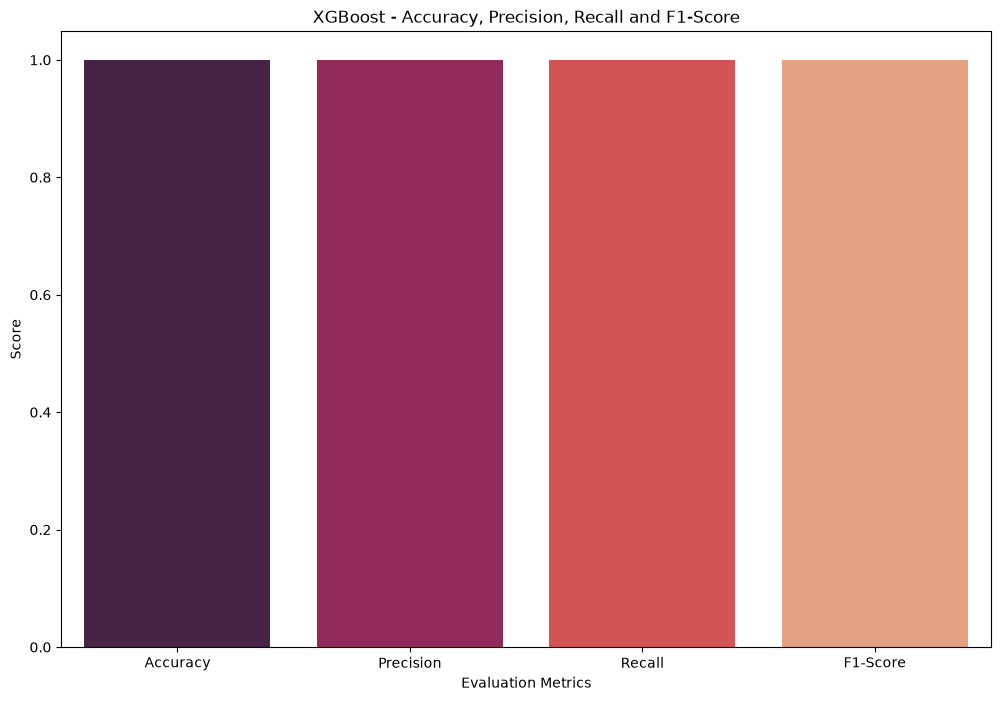

In [ ]:
season = ["Accuracy", "Precision", "Recall", "F1-Score"]
season_score = [xgboost_accuracy, xgboost_precision, xgboost_recall, xgboost_f1_score]

sns.barplot(x=season, y=season_score, palette="rocket")
plt.title("XGBoost - Accuracy, Precision, Recall and F1-Score")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()

# Comparison


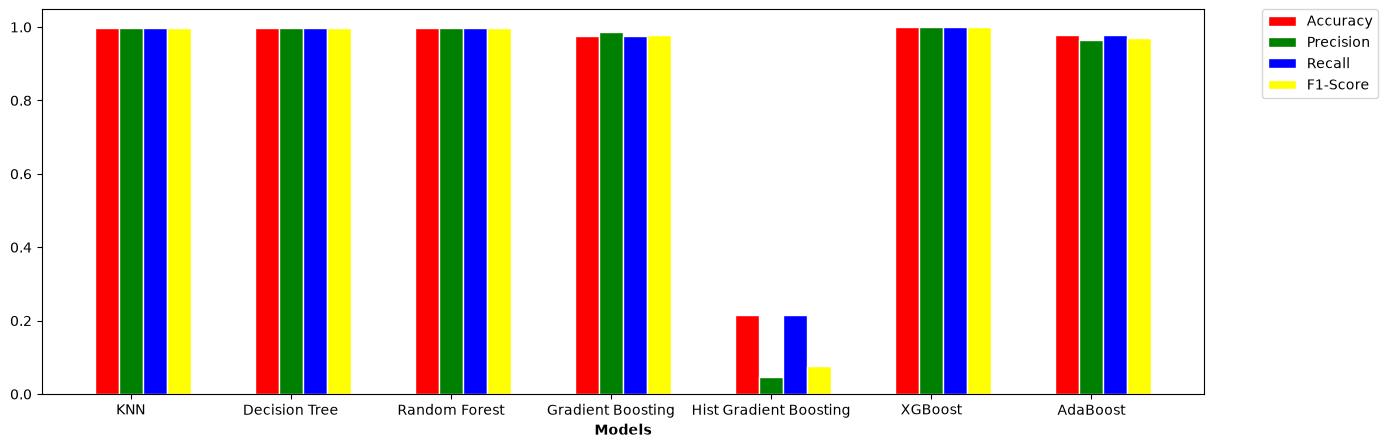

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "KNN",
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "Hist Gradient Boosting",
    "XGBoost",
    "AdaBoost",
]
accuracy = [
    k_nearest_neighbors_accuracy,
    decision_tree_accuracy,
    random_forest_classifier_accuracy,
    gradient_boosting_accuracy,
    hist_gradient_boosting_accuracy,
    xgboost_accuracy,
    ada_boost_accuracy,
]
precision = [
    k_nearest_neighbors_precision,
    decision_tree_precision,
    random_forest_classifier_precision,
    gradient_boosting_precision,
    hist_gradient_boosting_precision,
    xgboost_precision,
    ada_boost_precision,
]
recall = [
    k_nearest_neighbors_recall,
    decision_tree_recall,
    random_forest_classifier_recall,
    gradient_boosting_recall,
    hist_gradient_boosting_recall,
    xgboost_recall,
    ada_boost_recall,
]
f1_score = [
    k_nearest_neighbors_f1_score,
    decision_tree_f1_score,
    random_forest_classifier_f1_score,
    gradient_boosting_f1_score,
    hist_gradient_boosting_f1_score,
    xgboost_f1_score,
    ada_boost_f1_score,
]

barWidth = 0.15

r1 = np.arange(len(accuracy))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
r4 = [x + barWidth for x in r3]

plt.figure(figsize=(15, 5))

plt.bar(r1, accuracy, color="red", width=barWidth, edgecolor="white", label="Accuracy")
plt.bar(
    r2, precision, color="green", width=barWidth, edgecolor="white", label="Precision"
)
plt.bar(r3, recall, color="blue", width=barWidth, edgecolor="white", label="Recall")
plt.bar(
    r4, f1_score, color="yellow", width=barWidth, edgecolor="white", label="F1-Score"
)
plt.xlabel("Models", fontweight="bold")
plt.xticks([r + barWidth for r in range(len(accuracy))], models)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
plt.show()

# Deep Learning


## CNN


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

# Create a consecutive label mapping for CNN
cnn_labels = sorted(y_train.unique())
cnn_label_mapping = {label: i for i, label in enumerate(cnn_labels)}

y_train_cnn = y_train.map(cnn_label_mapping).astype(int)

# Keep only test samples whose classes were present in training
cnn_test_mask = y_test.isin(cnn_labels)

X_test_cnn = X_test.loc[cnn_test_mask]
y_test_cnn = y_test.loc[cnn_test_mask].map(cnn_label_mapping).astype(int)

# Number of features and classes
num_features = X_train.shape[1]
num_classes = len(cnn_labels)

# Define the CNN model
model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu",
        input_shape=(num_features, 1)
    )
)

model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(64, activation="relu"))
model.add(Dense(num_classes, activation="softmax"))

# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Reshape data for Conv1D
X_train_cnn = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test_cnn.values.reshape(X_test_cnn.shape[0], X_test_cnn.shape[1], 1)

# Train the model
model.fit(
    X_train_cnn,
    y_train_cnn,
    epochs=10,
    batch_size=32
)

# Evaluate the model
cnn_loss, cnn_accuracy = model.evaluate(
    X_test_cnn,
    y_test_cnn
)

print("CNN Accuracy:", cnn_accuracy * 100, "%")

NameError: name 'y_train' is not defined

In [ ]:
print("Prediciton:    ", model)
print("_" * 75)

print("Accuracy:" + "\t" + f"{(cnn_accuracy * 100)}%")
print("Loss:" + "\t\t" + f"{(cnn_loss * 100)}%")

Prediciton:     <Sequential name=sequential_3, built=True>
___________________________________________________________________________
Accuracy:	99.75858330726624%
Loss:		3.43678742647171%


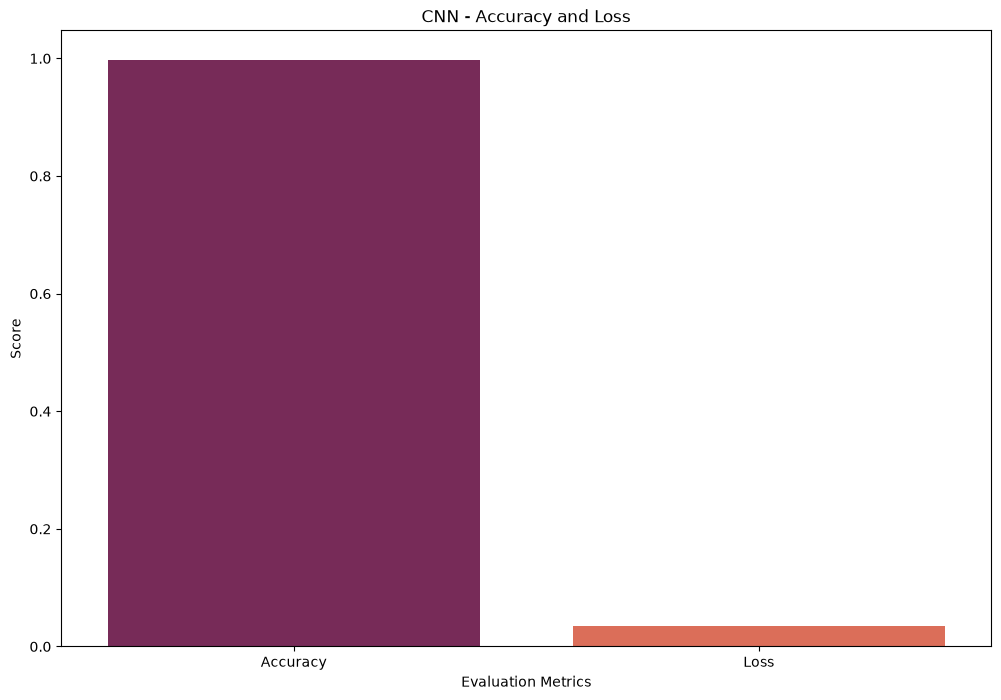

In [ ]:
season = ["Accuracy", "Loss"]
season_score = [cnn_accuracy, cnn_loss]

sns.barplot(x=season, y=season_score, palette="rocket")
plt.title("CNN - Accuracy and Loss")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()

## Autoencoder


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the Autoencoder model
model = Sequential()
model.add(Dense(128, activation="relu", input_shape=(num_features,)))
model.add(Dense(64, activation="relu"))
model.add(Dense(128, activation="relu"))
model.add(Dense(num_features, activation="linear"))

# Compile the model
model.compile(optimizer="adam", loss="mean_squared_error")

# Train the model
model.fit(X_train, X_train, epochs=10, batch_size=32)

# Use the trained model for anomaly detection
reconstructed_data = model.predict(X_test)
auto_encoder_loss = tf.keras.losses.mae(reconstructed_data, X_test)
auto_encoder_accuracy = tf.keras.metrics.binary_accuracy(reconstructed_data, X_test)

Epoch 1/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3038
Epoch 2/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1384
Epoch 3/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1123
Epoch 4/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1123
Epoch 5/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0728
Epoch 6/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0891
Epoch 7/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0696
Epoch 8/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0491
Epoch 9/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0556
Epoch 10/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0654
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 977us/step


In [ ]:
print("Prediciton:    ", model)
print('_' * 75)

print("Accuracy:" + "\t" + f"{(auto_encoder_accuracy * 100)}%")
print("Loss:" + "\t\t" + f"{(auto_encoder_loss * 100)}%")

Prediciton:     <Sequential name=sequential_4, built=True>
___________________________________________________________________________
Accuracy:	[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]%
Loss:		[ 0.52550686  0.50005768  0.55067338 ...  3.04711816  2.7016786
 14.56639749]%


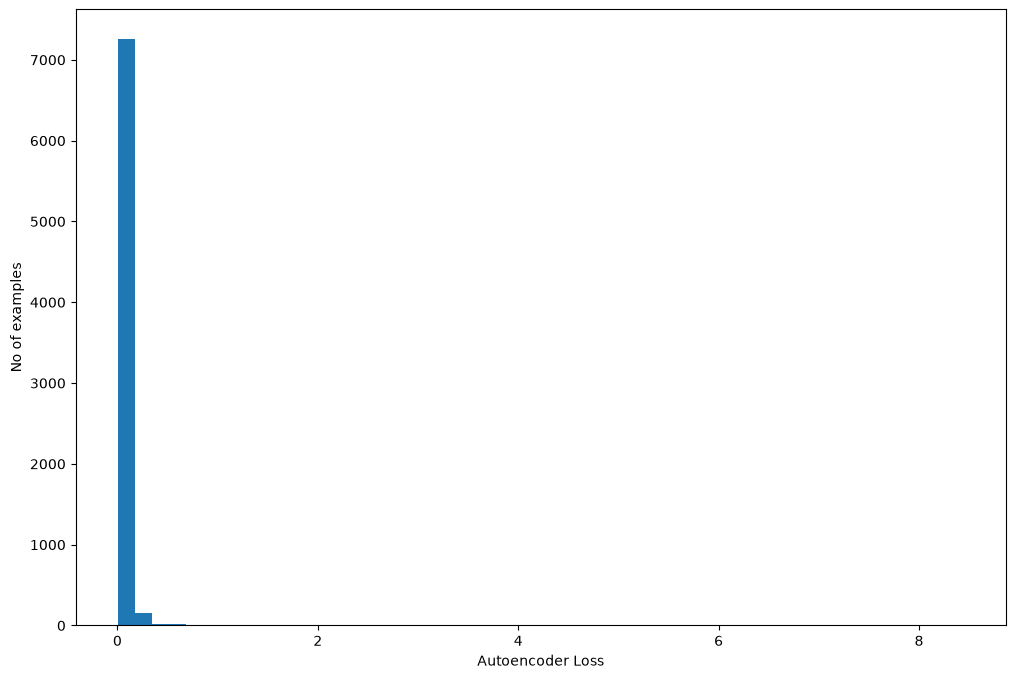

In [ ]:
# plot the loss distribution of the test set
plt.hist(auto_encoder_loss, bins=50)
plt.xlabel("Autoencoder Loss")
plt.ylabel("No of examples")
plt.show()

## Gated Recurrent Unit (GRU)


In [ ]:
# Apply GRU to the dataset

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

# Create consecutive label mapping for GRU
gru_labels = sorted(y_train.unique())
gru_label_mapping = {label: i for i, label in enumerate(gru_labels)}

y_train_gru = y_train.map(gru_label_mapping).astype(int)

# Keep only test samples whose classes were present during training
gru_test_mask = y_test.isin(gru_labels)

X_test_gru = X_test.loc[gru_test_mask]
y_test_gru = y_test.loc[gru_test_mask].map(gru_label_mapping).astype(int)

# Number of classes
num_classes_gru = len(gru_labels)

# Reshape data for GRU
X_train_gru = X_train.values.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test_gru = X_test_gru.values.reshape(
    X_test_gru.shape[0],
    X_test_gru.shape[1],
    1
)

# Define the GRU model
model = Sequential()

model.add(
    GRU(
        32,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(
    Dense(
        num_classes_gru,
        activation="softmax"
    )
)

# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the model
model.fit(
    X_train_gru,
    y_train_gru,
    epochs=10,
    batch_size=32
)

# Evaluate the model
gru_loss, gru_accuracy = model.evaluate(
    X_test_gru,
    y_test_gru
)

print("GRU Accuracy:", gru_accuracy * 100, "%")

Epoch 1/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8762 - loss: 0.5346
Epoch 2/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9751 - loss: 0.1002
Epoch 3/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9843 - loss: 0.0672
Epoch 4/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9892 - loss: 0.0513
Epoch 5/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9904 - loss: 0.0425
Epoch 6/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9915 - loss: 0.0391
Epoch 7/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9912 - loss: 0.0370
Epoch 8/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9925 - loss: 0.0299
Epoch 9/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9933 - loss: 0.0287
Epoch 10/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9930 - loss: 0.0291
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9942 - loss: 0.0224
GRU Accuracy: 99.42328333854675 %


In [ ]:
print("Prediciton:    ", model)
print('_' * 75)

print("Accuracy:" + "\t" + f"{(gru_accuracy * 100)}%")
print("Loss:" + "\t\t" + f"{(gru_loss * 100)}%")

Prediciton:     <Sequential name=sequential_6, built=True>
___________________________________________________________________________
Accuracy:	99.42328333854675%
Loss:		2.2402342408895493%


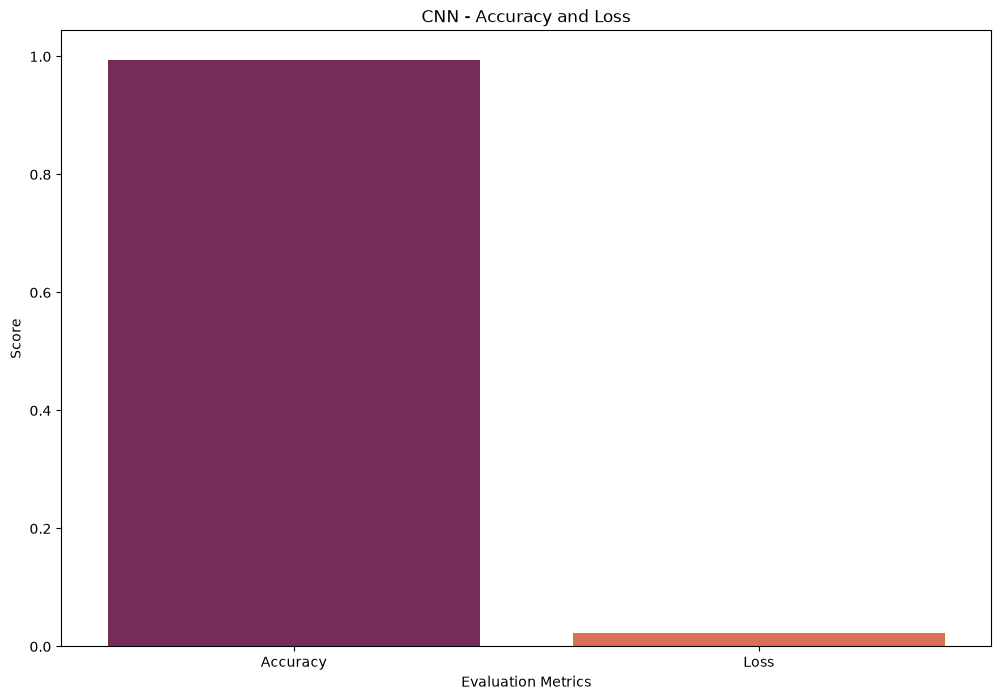

In [ ]:
season = ["Accuracy", "Loss"]
season_score = [gru_accuracy, gru_loss]

sns.barplot(x=season, y=season_score, palette="rocket")
plt.title("CNN - Accuracy and Loss")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()